# Torus Longitudinal Velocity Disentanglement Analysis: 64/128/64 Binary Margin Adv

This notebook analyzes the experiment:
- `examples/Torus_subset_100_id_age_progression/longitudinal_age_disease_conditioned_cocycle_shape_pair_loss_multiple_pairs_disentangled_velocity_64_128_64_binary_margin_adv`

It is intended to be a full evaluation notebook, not a scaffold. It covers:
1. model + metadata loading,
2. GT vs predicted test-time trajectories,
3. age-only / disease-only / residual-only traversals,
4. healthy vs diseased counterfactuals from the same fitted subject,
5. component speed curves,
6. held-out leakage/probe metrics,
7. baseline black-box comparison.

In [3]:
import json
import math
import random
import re
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import trimesh
import skimage.measure
import scipy.ndimage as ndi
from scipy.spatial import cKDTree
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import r2_score, mean_absolute_error, roc_auc_score, accuracy_score
from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from IPython.display import display

ROOT = Path('/home/jakaria/INR/Deep3DComp')
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from deep_sdf import data, mesh
from train_deep_sdf_longitudinal_disentangled_flow_64_128_64_adv import (
    optimize_subject_anchor_from_observations,
    _apply_temporal_flow_interval,
)
from networks.longitudinal_disentangled_flow_64_128_64_adv import build_temporal_flow

plt.style.use('default')
pd.set_option('display.max_columns', 200)
random.seed(7)
np.random.seed(7)
torch.manual_seed(7)

EXP_DIR = ROOT / 'examples' / 'Torus_subset_100_id_age_progression' / 'longitudinal_age_disease_conditioned_cocycle_shape_pair_loss_multiple_pairs_disentangled_velocity_64_128_64_binary_margin_adv'
BASELINE_EXP_DIR = ROOT / 'examples' / 'Torus_subset_100_id_age_progression' / 'longitudinal_age_disease_conditioned_cocycle_shape'
SPECS = json.loads((EXP_DIR / 'specs.json').read_text())
BASELINE_SPECS = json.loads((BASELINE_EXP_DIR / 'specs.json').read_text())

CHECKPOINT = 'latest'
BASELINE_CHECKPOINT = 'latest'
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

LATENT_SIZE = int(SPECS['CodeLength'])
CLAMP_DIST = float(SPECS.get('ClampingDistance', 0.1))
TIME_KEY = str(SPECS.get('LongitudinalTimeKey', 'age_norm'))
TIME_MODE = str(SPECS.get('LongitudinalTimeNormalization', 'none')).lower()
USE_AGE_CONDITIONING = bool(SPECS.get('UseAgeConditioning', False))
AGE_COND_DIM = int(SPECS.get('AgeConditionDim', 0))
GRID_RES_VIS = 160
GRID_RES_ANALYSIS = 96
SMOOTH_SIGMA = 0.6
OBS_OPT_STEPS = int(SPECS.get('EvalTestOptimizationSteps', 1000))
OBS_OPT_SAMPLES = int(SPECS.get('EvalTestAnchorNumSamples', 16384))
OBS_OPT_LR = float(SPECS.get('EvalTestAnchorLR', 5e-3))
OBS_INIT_STD = float(SPECS.get('EvalTestAnchorInitStd', 0.01))
OBS_CODE_REG = float(SPECS.get('EvalTestAnchorCodeRegLambda', 1e-4))
CODE_BOUND = SPECS.get('CodeBound', None)
COMPOSED_MAX_DT_VIS = float(SPECS.get('EvalTestMaxRolloutDt', 0.0))
if COMPOSED_MAX_DT_VIS <= 0.0:
    COMPOSED_MAX_DT_VIS = 0.05

age_keys = SPECS.get('AgeConditionKeys', None)
if age_keys is None:
    age_keys = [str(SPECS.get('AgeConditionKey', 'age_norm'))]
elif isinstance(age_keys, str):
    age_keys = [age_keys]
else:
    age_keys = [str(k) for k in age_keys]
AGE_CONDITION_KEYS = [k for k in age_keys if k]

print('Experiment:', EXP_DIR)
print('Baseline experiment:', BASELINE_EXP_DIR)
print('Checkpoint:', CHECKPOINT)
print('Device:', DEVICE)
print('Time key/mode:', TIME_KEY, TIME_MODE)
print('Age conditioning:', USE_AGE_CONDITIONING, AGE_COND_DIM, AGE_CONDITION_KEYS)

Experiment: /home/jakaria/INR/Deep3DComp/examples/Torus_subset_100_id_age_progression/longitudinal_age_disease_conditioned_cocycle_shape_pair_loss_multiple_pairs_disentangled_velocity_64_128_64_binary_margin_adv
Baseline experiment: /home/jakaria/INR/Deep3DComp/examples/Torus_subset_100_id_age_progression/longitudinal_age_disease_conditioned_cocycle_shape
Checkpoint: latest
Device: cuda
Time key/mode: age_norm none
Age conditioning: True 1 ['diagnosis']


In [4]:
# ---- Labels + splits ----

def _resolve_path(path_value, exp_dir=EXP_DIR):
    p = Path(path_value)
    if p.is_absolute() and p.exists():
        return p
    for cand in [exp_dir / path_value, ROOT / path_value, Path.cwd() / path_value]:
        if cand.exists():
            return cand
    return p


def load_labels_table(labels_path):
    obj = torch.load(labels_path, map_location='cpu')
    if isinstance(obj, dict) and 'records' in obj and isinstance(obj['records'], list):
        records = [r for r in obj['records'] if isinstance(r, dict)]
        df = pd.DataFrame(records)
        label_map = {}
        for r in records:
            k = None
            if r.get('mesh_path', None) is not None:
                k = Path(str(r['mesh_path'])).stem
            elif 'name' in r:
                k = Path(str(r['name'])).stem
            if k:
                label_map[k] = r
        return df, label_map
    if isinstance(obj, dict):
        rows = []
        label_map = {}
        for k, v in obj.items():
            if isinstance(v, dict):
                row = {'scan_key': str(k)}
                row.update(v)
                rows.append(row)
                label_map[str(k)] = v
        return pd.DataFrame(rows), label_map
    raise RuntimeError(f'Unsupported labels format: {type(obj)}')

TRAIN_SPLIT_PATH = _resolve_path(SPECS['TrainSplit'])
TEST_SPLIT_PATH = _resolve_path(SPECS['TestSplit'])
LABELS_PATH = _resolve_path(SPECS['AgeMetadataFile'])
TRAIN_SPLIT = json.loads(TRAIN_SPLIT_PATH.read_text())
TEST_SPLIT = json.loads(TEST_SPLIT_PATH.read_text())
LABEL_DF_RAW, LABEL_MAP = load_labels_table(LABELS_PATH)

if 'scan_key' not in LABEL_DF_RAW.columns:
    if 'mesh_path' in LABEL_DF_RAW.columns:
        LABEL_DF_RAW['scan_key'] = LABEL_DF_RAW['mesh_path'].astype(str).map(lambda x: Path(x).stem)
    else:
        LABEL_DF_RAW['scan_key'] = LABEL_DF_RAW.index.astype(str)

for c in ['diagnosis', 'time_index', 'tau_years', 'age', 'age_norm', 'thickness_t', 'bump_height', 'radius', 'thickness']:
    if c in LABEL_DF_RAW.columns:
        LABEL_DF_RAW[c] = pd.to_numeric(LABEL_DF_RAW[c], errors='coerce')

if 'subject_id' not in LABEL_DF_RAW.columns:
    LABEL_DF_RAW['subject_id'] = LABEL_DF_RAW['scan_key'].map(lambda s: '_'.join(str(s).split('_')[:2]))

LABEL_DF = LABEL_DF_RAW.sort_values(['subject_id', 'time_index'], na_position='last').reset_index(drop=True)

age_slope = None
age_intercept = None
if {'age_norm', 'age'}.issubset(LABEL_DF.columns):
    m = LABEL_DF[['age_norm', 'age']].dropna()
    if len(m) >= 2:
        coef = np.polyfit(m['age_norm'].to_numpy(), m['age'].to_numpy(), 1)
        age_slope = float(coef[0])
        age_intercept = float(coef[1])

print('Labels path:', LABELS_PATH)
print('Train scans:', len(TRAIN_SPLIT), '| Test scans:', len(TEST_SPLIT))
print('Train subjects:', len({x.split('_t')[0] for x in TRAIN_SPLIT}), '| Test subjects:', len({x.split('_t')[0] for x in TEST_SPLIT}))
display(LABEL_DF.head(8))

Labels path: /home/jakaria/torus_creation/torus_age_disease_longitudinal_100ids_5tp_flat/labels.pt
Train scans: 400 | Test scans: 75
Train subjects: 80 | Test subjects: 15


,scan_key,mesh_path,subject_id,subject_index,diagnosis,time_index,tau_years,age,scan_age,age_norm,bump_height,bump_speed_gt,bump_accel_gt,baseline_age,visit_gap_years,radius,thickness,thickness0,thickness_t,global_age_loss,global_dis_gap0,global_dis_age_loss,global_dis_loss,noise_scale,noise_strength,seed,bump_width,angle_deg,scale
0,ID_000_t0,obj_files/ID_000_t0.obj,ID_000,0,1,0,0.000000,77.595505,77.595505,0.689888,5.213349,NaN,NaN,77.595505,0.000000,0.243579,0.065593,0.102560,0.065593,0.013802,0.012,0.011164,0.023164,15.934537,9.741001,52,0.006216,-0.451818,1.058104
1,ID_000_t1,obj_files/ID_000_t1.obj,ID_000,0,1,1,1.453806,79.049309,79.049309,0.726233,5.589939,NaN,NaN,77.595505,1.453806,0.243579,0.062242,0.102560,0.062242,0.015295,0.012,0.013023,0.025023,15.934537,9.741001,52,0.006216,-0.451818,1.058104
2,ID_000_t2,obj_files/ID_000_t2.obj,ID_000,0,1,2,3.082904,80.678406,80.678406,0.766960,6.059136,NaN,NaN,77.595505,1.629098,0.243579,0.058162,0.102560,0.058162,0.017059,0.012,0.015339,0.027339,15.934537,9.741001,52,0.006216,-0.451818,1.058104
3,ID_000_t3,obj_files/ID_000_t3.obj,ID_000,0,1,3,4.355635,81.951141,81.951141,0.798779,6.462135,NaN,NaN,77.595505,1.272730,0.243579,0.054728,0.102560,0.054728,0.018503,0.012,0.017328,0.029328,15.934537,9.741001,52,0.006216,-0.451818,1.058104
4,ID_000_t4,obj_files/ID_000_t4.obj,ID_000,0,1,4,6.094478,83.689980,83.689980,0.842249,7.067004,NaN,NaN,77.595505,1.738843,0.243579,0.049673,0.102560,0.049673,0.020572,0.012,0.020314,0.032314,15.934537,9.741001,52,0.006216,-0.451818,1.058104
5,ID_001_t0,obj_files/ID_001_t0.obj,ID_001,1,0,0,0.000000,55.861927,55.861927,0.146548,0.000000,NaN,NaN,55.861928,0.000000,0.248968,0.100732,0.101355,0.100732,0.000623,0.000,0.000000,0.000000,15.555798,9.452666,48,0.006300,1.283673,1.005163
6,ID_001_t1,obj_files/ID_001_t1.obj,ID_001,1,0,1,1.392299,57.254227,57.254227,0.181356,0.000000,NaN,NaN,55.861928,1.392299,0.248968,0.100401,0.101355,0.100401,0.000954,0.000,0.000000,0.000000,15.555798,9.452666,48,0.006300,1.283673,1.005163
7,ID_001_t2,obj_files/ID_001_t2.obj,ID_001,1,0,2,2.545269,58.407196,58.407196,0.210180,0.000000,NaN,NaN,55.861928,1.152970,0.248968,0.100074,0.101355,0.100074,0.001281,0.000,0.000000,0.000000,15.555798,9.452666,48,0.006300,1.283673,1.005163


In [5]:
# ---- Model, metadata, mesh, plotting helpers ----

SID_RE = re.compile(r"__sid-(\d+)__")
TP_RE = re.compile(r"__tp-(\d+)__")
TORUS_RE = re.compile(r"^(?:ID|id)_(\d+)_t(\d+)$")


def base_id(name):
    return Path(name).stem


def parse_sid_tp(name_or_base):
    b = base_id(name_or_base)
    sm = SID_RE.search(b)
    tm = TP_RE.search(b)
    if sm is not None and tm is not None:
        return sm.group(1), int(tm.group(1))
    mm = TORUS_RE.match(b)
    if mm is not None:
        return mm.group(1), int(mm.group(2))
    raise RuntimeError(f'Cannot parse sid/tp from: {b}')


def apply_temporal_flow(flow_net, z, s, t, age_cond=None):
    return z + (t - s) * flow_net(z, s, t, age_cond=age_cond)


def load_decoder_and_flow(exp_dir, specs, checkpoint='latest'):
    arch = __import__('networks.' + specs['NetworkArch'], fromlist=['Decoder'])
    decoder = arch.Decoder(int(specs['CodeLength']), **specs['NetworkSpecs']).to(DEVICE)
    flow = build_temporal_flow(
        specs,
        int(specs['CodeLength']),
        list(specs.get('FlowHiddenDims', [256, 256])),
        age_condition_dim=int(specs.get('AgeConditionDim', 0)) if bool(specs.get('UseAgeConditioning', False)) else 0,
    ).to(DEVICE)

    model_dir = exp_dir / 'ModelParameters'
    ckpt_path = model_dir / f'{checkpoint}.pth'
    resolved_name = str(checkpoint)
    if not ckpt_path.exists() and str(checkpoint) == 'latest':
        numeric = []
        for pth in model_dir.glob('*.pth'):
            if pth.stem.isdigit():
                numeric.append((int(pth.stem), pth))
        if numeric:
            numeric.sort(key=lambda x: x[0])
            resolved_name = str(numeric[-1][0])
            ckpt_path = numeric[-1][1]
    payload = torch.load(ckpt_path, map_location=DEVICE)
    decoder.load_state_dict({k.replace('module.', ''): v for k, v in payload['model_state_dict'].items()}, strict=False)
    flow.load_state_dict(payload['flow_state_dict'], strict=True)
    decoder.eval()
    flow.eval()
    return decoder, flow, int(payload.get('epoch', -1)), resolved_name


def load_train_subject_anchors(exp_dir, checkpoint='latest'):
    lat_dir = exp_dir / 'LatentCodes'
    ckpt = lat_dir / f'{checkpoint}.pth'
    if not ckpt.exists() and str(checkpoint) == 'latest':
        numeric = []
        for pth in lat_dir.glob('*.pth'):
            if pth.stem.isdigit():
                numeric.append((int(pth.stem), pth))
        if numeric:
            numeric.sort(key=lambda x: x[0])
            ckpt = numeric[-1][1]
    payload = torch.load(ckpt, map_location='cpu')
    lat = payload['latent_codes']
    if isinstance(lat, dict):
        w = lat['weight']
    else:
        w = lat
    if w.dim() == 3 and w.shape[1] == 1:
        w = w.squeeze(1)
    return w.detach().cpu().float()


def scan_record_from_label_map(scan_key):
    rec = LABEL_MAP.get(scan_key, None)
    if rec is None:
        raise KeyError(f'Missing label metadata for {scan_key}')
    return rec


def condition_vector_from_record(rec):
    if not USE_AGE_CONDITIONING:
        return None
    vals = []
    for k in AGE_CONDITION_KEYS:
        vals.append(float(rec[k]))
    return torch.tensor(vals, dtype=torch.float32)


def build_split_meta(split_entries, split_name):
    data_source = Path(SPECS['DataSource'])
    data_mesh = Path(SPECS['DataSourceMesh'])
    subject_to_records = {}
    all_times = []
    for item in split_entries:
        b = base_id(item)
        sid, tp = parse_sid_tp(b)
        sdf_path = data_source / f'{b}.npz'
        gt_path = data_mesh / f'{b}.obj'
        if not sdf_path.exists() or not gt_path.exists():
            continue
        label_rec = scan_record_from_label_map(b)
        t_val = float(label_rec[TIME_KEY])
        rec = {
            'name': b,
            'sid': sid,
            'tp_raw': int(tp),
            'tp_user': int(tp + 1),
            'sdf_path': sdf_path,
            'gt_path': gt_path,
            'time': t_val,
            'label': label_rec,
            'diagnosis': int(label_rec.get('diagnosis', -1)),
            'age': float(label_rec.get('age', np.nan)),
            'age_norm': float(label_rec.get('age_norm', np.nan)),
            'cond': condition_vector_from_record(label_rec),
        }
        subject_to_records.setdefault(sid, []).append(rec)
        all_times.append(t_val)
    for sid in list(subject_to_records.keys()):
        subject_to_records[sid] = sorted(subject_to_records[sid], key=lambda r: float(r['time']))
    return {
        'name': split_name,
        'subject_to_records': subject_to_records,
        'global_min': float(np.min(all_times)) if all_times else 0.0,
        'global_max': float(np.max(all_times)) if all_times else 1.0,
        'subject_ids_sorted': sorted(subject_to_records.keys(), key=lambda x: int(x)),
    }


def load_sdf_ram(record):
    sdf_data = data.read_sdf_samples_into_ram(str(record['sdf_path']))
    sdf_data[0] = sdf_data[0][torch.randperm(sdf_data[0].shape[0])]
    sdf_data[1] = sdf_data[1][torch.randperm(sdf_data[1].shape[0])]
    return sdf_data


def observations_from_records(records, observed_count):
    obs = []
    for r in sorted(records, key=lambda x: float(x['time']))[:int(observed_count)]:
        item = {'samples': load_sdf_ram(r), 'time': float(r['time'])}
        if r['cond'] is not None:
            item['age_cond'] = r['cond'].clone()
        obs.append(item)
    return obs


def fit_anchor(records, observed_count=1):
    obs = observations_from_records(records, observed_count=observed_count)
    anchor, loss_hist = optimize_subject_anchor_from_observations(
        decoder,
        flow_net,
        LATENT_SIZE,
        obs,
        clamp_dist=CLAMP_DIST,
        num_iterations=OBS_OPT_STEPS,
        num_samples=OBS_OPT_SAMPLES,
        lr=OBS_OPT_LR,
        init_std=OBS_INIT_STD,
        code_reg_lambda=OBS_CODE_REG,
        code_bound=CODE_BOUND,
        use_pair_forward_consistency=False,
        use_pair_backward_consistency=False,
        use_general_cocycle_consistency=False,
        use_age_conditioning=USE_AGE_CONDITIONING,
    )
    return anchor, loss_hist


def as_mesh(mesh_like):
    if mesh_like is None:
        return None
    if isinstance(mesh_like, trimesh.Scene):
        return trimesh.util.concatenate(tuple(g for g in mesh_like.geometry.values()))
    return mesh_like


def latent_to_mesh(decoder, latent, grid_res=GRID_RES_VIS):
    m = mesh.create_mesh(decoder, latent, N=int(grid_res), max_batch=int(2**18), return_trimesh=True)
    return as_mesh(m)


def condition_for_record(record, device, dtype):
    if record['cond'] is None:
        return None
    return record['cond'].to(device=device, dtype=dtype).view(1, -1)


def condition_for_diagnosis(diag_value, device, dtype):
    if not USE_AGE_CONDITIONING:
        return None
    vals = []
    for k in AGE_CONDITION_KEYS:
        if k == 'diagnosis':
            vals.append(float(diag_value))
        else:
            vals.append(float(LABEL_DF[k].dropna().iloc[0]))
    return torch.tensor(vals, dtype=dtype, device=device).view(1, -1)


def predict_latent_from_anchor(anchor, baseline_t, target_t, cond_t=None, composed=False, max_dt=COMPOSED_MAX_DT_VIS):
    if composed:
        return _apply_temporal_flow_interval(flow_net, anchor, t_start=float(baseline_t), t_end=float(target_t), max_dt=float(max_dt), age_end_cond=cond_t)
    s = torch.full((anchor.shape[0], 1), float(baseline_t), device=anchor.device, dtype=anchor.dtype)
    t = torch.full((anchor.shape[0], 1), float(target_t), device=anchor.device, dtype=anchor.dtype)
    return apply_temporal_flow(flow_net, anchor, s, t, age_cond=cond_t)


def disentangled_component_vectors(z_source, s_value, t_value, cond_t):
    flow = flow_net.module if hasattr(flow_net, 'module') else flow_net
    s = torch.full((z_source.shape[0], 1), float(s_value), device=z_source.device, dtype=z_source.dtype)
    t = torch.full((z_source.shape[0], 1), float(t_value), device=z_source.device, dtype=z_source.dtype)
    comp = flow.velocity_components(z_source, s, t, age_cond=cond_t)
    z0 = torch.zeros(z_source.shape[0], flow.residual_dim, device=z_source.device, dtype=z_source.dtype)
    age_full = torch.cat([comp['age'], torch.zeros(z_source.shape[0], flow.disease_dim, device=z_source.device, dtype=z_source.dtype), z0], dim=1)
    disease_full = torch.cat([torch.zeros(z_source.shape[0], flow.age_dim, device=z_source.device, dtype=z_source.dtype), comp['disease'], z0], dim=1)
    residual_full = torch.cat([torch.zeros(z_source.shape[0], flow.age_dim + flow.disease_dim, device=z_source.device, dtype=z_source.dtype), comp['residual']], dim=1)
    return comp, age_full, disease_full, residual_full


def latent_speed_components(z_t, t_value, cond_t):
    flow = flow_net.module if hasattr(flow_net, 'module') else flow_net
    t = torch.full((z_t.shape[0], 1), float(t_value), device=z_t.device, dtype=z_t.dtype)
    comp = flow.velocity_components(z_t, t, t, age_cond=cond_t)
    return {
        'total': float(torch.norm(comp['velocity'], dim=1).mean().item()),
        'age': float(torch.norm(comp['age'], dim=1).mean().item()),
        'disease_raw': float(torch.norm(comp['disease_raw'], dim=1).mean().item()),
        'disease': float(torch.norm(comp['disease'], dim=1).mean().item()),
        'residual': float(torch.norm(comp['residual'], dim=1).mean().item()),
    }


def sample_mesh_points(mesh_obj, n=6000):
    mesh_obj = as_mesh(mesh_obj)
    if mesh_obj is None:
        return None
    pts, _ = trimesh.sample.sample_surface(mesh_obj, int(n))
    return pts


def symmetric_chamfer(a_mesh, b_mesh, n=6000):
    pa = sample_mesh_points(a_mesh, n=n)
    pb = sample_mesh_points(b_mesh, n=n)
    if pa is None or pb is None or len(pa) == 0 or len(pb) == 0:
        return np.nan
    ta = cKDTree(pa)
    tb = cKDTree(pb)
    da, _ = tb.query(pa, k=1)
    db, _ = ta.query(pb, k=1)
    return float(np.mean(da**2) + np.mean(db**2))


def _mesh_bounds(meshes):
    verts = []
    for m in meshes:
        m = as_mesh(m)
        if m is not None and len(m.vertices) > 0:
            verts.append(np.asarray(m.vertices))
    if not verts:
        return None, None
    allv = np.concatenate(verts, axis=0)
    return allv.min(axis=0), allv.max(axis=0)


def draw_mesh(ax, mesh_obj, title, color='#b8e8b8', mins=None, maxs=None):
    mesh_obj = as_mesh(mesh_obj)
    if mesh_obj is None or len(mesh_obj.vertices) == 0:
        ax.set_title(title + '[empty]')
        ax.axis('off')
        return
    verts = np.asarray(mesh_obj.vertices)
    faces = np.asarray(mesh_obj.faces)
    tri = verts[faces]
    poly = Poly3DCollection(tri, alpha=0.92, facecolor=color, edgecolor='none')
    ax.add_collection3d(poly)
    if mins is None or maxs is None:
        mins = verts.min(axis=0)
        maxs = verts.max(axis=0)
    center = 0.5 * (mins + maxs)
    radius = 0.55 * np.max(maxs - mins + 1e-8)
    ax.set_xlim(center[0] - radius, center[0] + radius)
    ax.set_ylim(center[1] - radius, center[1] + radius)
    ax.set_zlim(center[2] - radius, center[2] + radius)
    ax.view_init(elev=18, azim=135)
    ax.set_box_aspect([1, 1, 1])
    ax.set_axis_off()
    ax.set_title(title, fontsize=10)


def plot_mesh_triplets(rows, suptitle, colors=None):
    meshes = [r['mesh'] for r in rows]
    mins, maxs = _mesh_bounds(meshes)
    fig = plt.figure(figsize=(3.7 * len(rows), 4.0))
    for i, r in enumerate(rows):
        ax = fig.add_subplot(1, len(rows), i + 1, projection='3d')
        col = colors[i] if colors is not None else '#b8e8b8'
        draw_mesh(ax, r['mesh'], r['title'], color=col, mins=mins, maxs=maxs)
    plt.suptitle(suptitle, fontsize=13)
    plt.tight_layout()
    plt.show()


def plot_metric_curves(df, title):
    fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
    for key, color in [('age', 'tab:blue'), ('disease', 'tab:red'), ('residual', 'tab:green')]:
        axes[0].plot(df['age_years'], df[f'speed_{key}'], marker='o', color=color, label=key)
    axes[0].plot(df['age_years'], df['speed_total'], marker='o', color='black', linewidth=2.2, label='total')
    axes[0].set_title('Component speed vs age')
    axes[0].set_xlabel('Age')
    axes[0].set_ylabel('speed')
    axes[0].legend()
    axes[0].grid(alpha=0.25)

    axes[1].plot(df['age_years'], df['chamfer_to_full'], marker='o', color='tab:purple')
    axes[1].set_title('Component traversal distance to full prediction')
    axes[1].set_xlabel('Age')
    axes[1].set_ylabel('Chamfer to full')
    axes[1].grid(alpha=0.25)

    axes[2].plot(df['age_years'], df['disease_norm'], marker='o', color='tab:red', label='disease')
    axes[2].plot(df['age_years'], df['residual_norm'], marker='o', color='tab:green', label='residual')
    axes[2].set_title('Disease/residual norms vs age')
    axes[2].set_xlabel('Age')
    axes[2].set_ylabel('norm')
    axes[2].legend()
    axes[2].grid(alpha=0.25)
    plt.suptitle(title, fontsize=13)
    plt.tight_layout()
    plt.show()

In [6]:
# ---- Build train/test metadata + load models ----

TRAIN_META = build_split_meta(TRAIN_SPLIT, split_name='train')
TEST_META = build_split_meta(TEST_SPLIT, split_name='test')

print('Train subjects:', len(TRAIN_META['subject_to_records']))
print('Test subjects:', len(TEST_META['subject_to_records']))

def pick_subject(meta, diagnosis=None, min_scans=5):
    cands = []
    for sid, recs in meta['subject_to_records'].items():
        if len(recs) < int(min_scans):
            continue
        if diagnosis is not None and int(recs[0]['diagnosis']) != int(diagnosis):
            continue
        cands.append(sid)
    if not cands:
        raise RuntimeError('No matching subject found')
    return sorted(cands, key=lambda x: int(x))[0]

TEST_SID_HEALTHY = pick_subject(TEST_META, diagnosis=0, min_scans=5)
TEST_SID_DISEASED = pick_subject(TEST_META, diagnosis=1, min_scans=5)
print('Selected healthy SID:', TEST_SID_HEALTHY)
print('Selected diseased SID:', TEST_SID_DISEASED)

decoder, flow_net, epoch_loaded, resolved_ckpt = load_decoder_and_flow(EXP_DIR, SPECS, checkpoint=CHECKPOINT)
baseline_decoder, baseline_flow, baseline_epoch_loaded, baseline_resolved_ckpt = load_decoder_and_flow(BASELINE_EXP_DIR, BASELINE_SPECS, checkpoint=BASELINE_CHECKPOINT)
print('Current checkpoint epoch:', epoch_loaded, '| resolved:', resolved_ckpt)
print('Baseline checkpoint epoch:', baseline_epoch_loaded, '| resolved:', baseline_resolved_ckpt)

Train subjects: 80
Test subjects: 15
Selected healthy SID: 027
Selected diseased SID: 004
Current checkpoint epoch: 800 | resolved: latest
Baseline checkpoint epoch: 2000 | resolved: latest


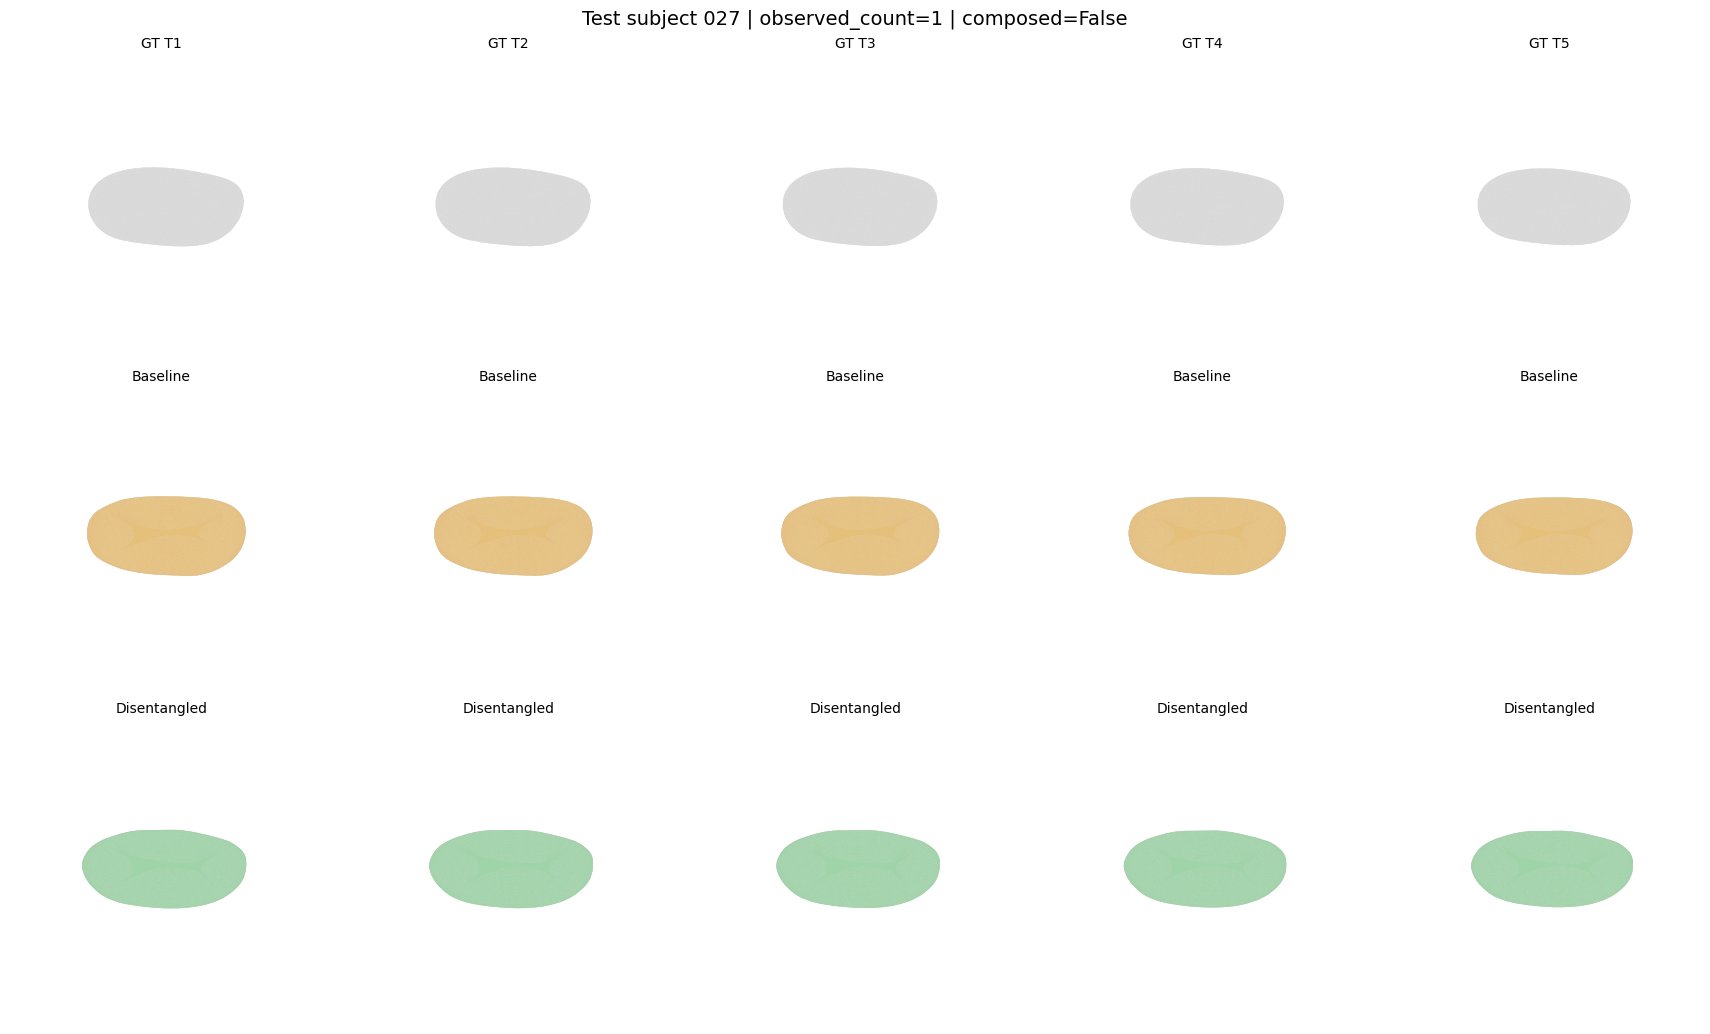

,tp_user,age,diagnosis,baseline_chamfer,disentangled_chamfer
0,1,77.962471,0,0.001562,0.001763
1,2,78.649971,0,0.001540,0.001750
2,3,79.368477,0,0.001557,0.001762
3,4,81.046677,0,0.001518,0.001785
4,5,81.998978,0,0.001546,0.001808


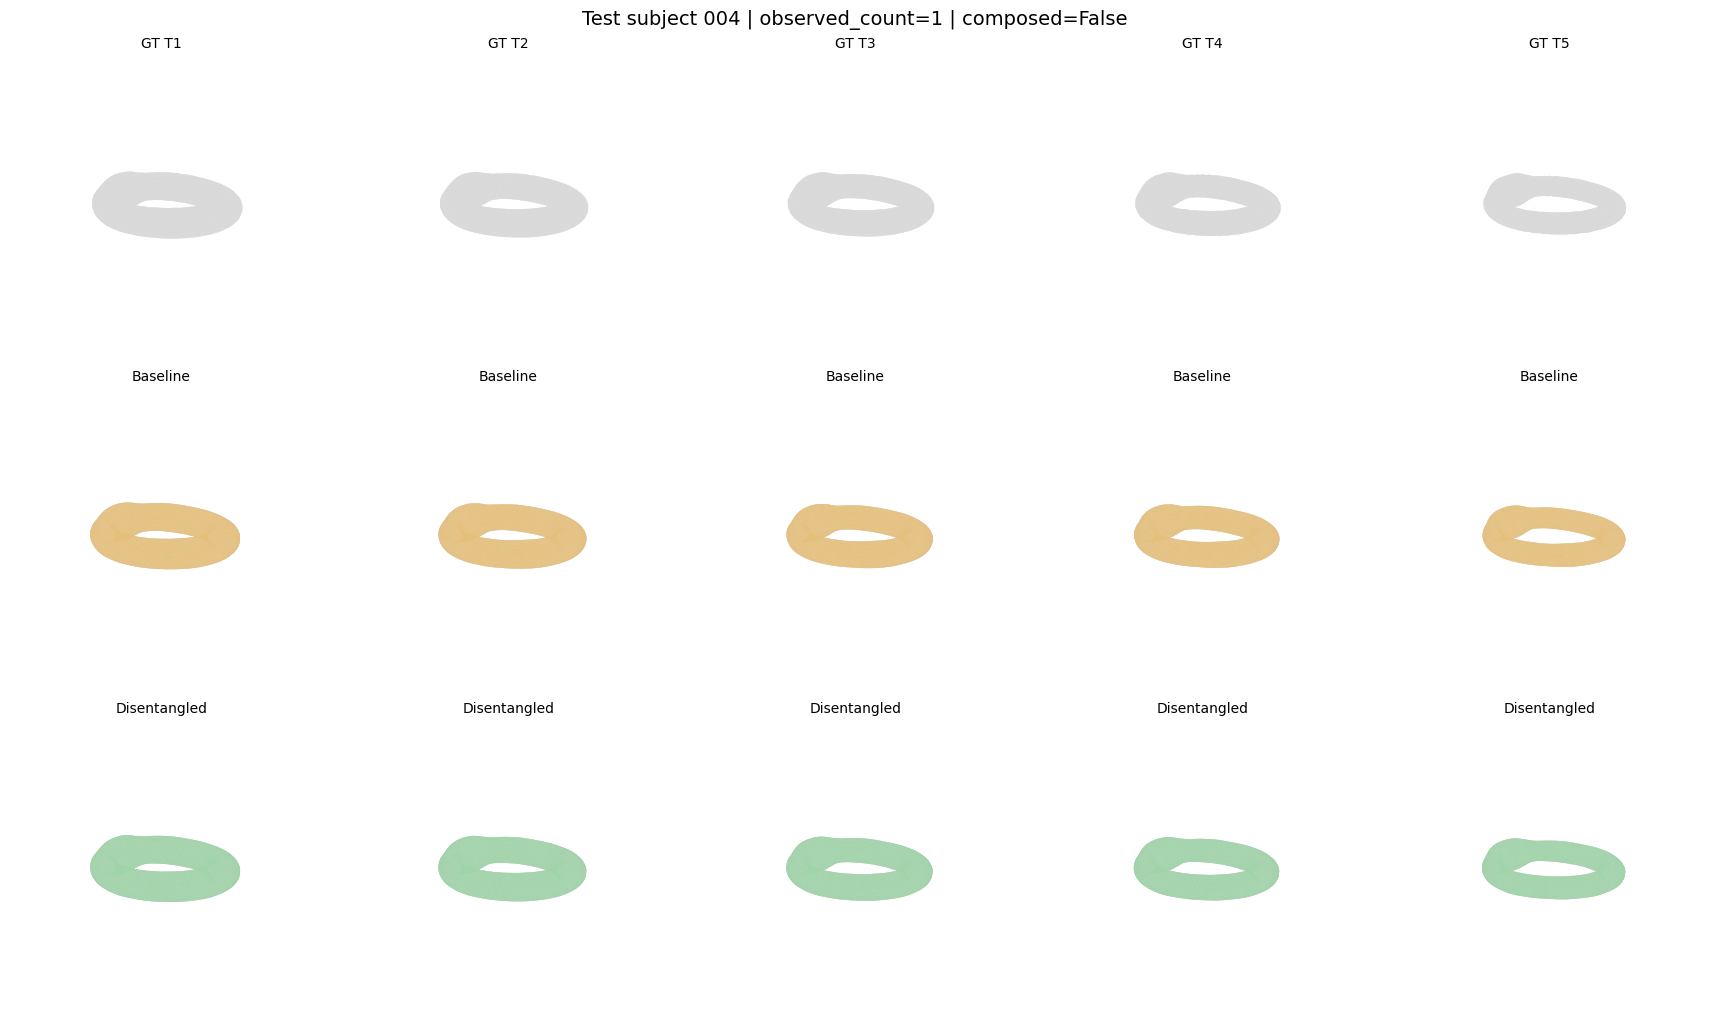

,tp_user,age,diagnosis,baseline_chamfer,disentangled_chamfer
0,1,78.753929,1,0.000724,0.000718
1,2,80.586525,1,0.000611,0.000634
2,3,82.017929,1,0.000527,0.000543
3,4,82.758339,1,0.000493,0.000505
4,5,84.678932,1,0.000406,0.000458


In [7]:
# ---- GT vs predicted trajectories: current model vs baseline black-box ----

def forecast_rows(decoder_obj, flow_obj, records, observed_count=1, composed=False, max_dt=COMPOSED_MAX_DT_VIS):
    global decoder, flow_net
    decoder_saved, flow_saved = decoder, flow_net
    decoder, flow_net = decoder_obj, flow_obj
    try:
        anchor, loss_hist = fit_anchor(records, observed_count=observed_count)
        baseline_t = float(records[0]['time'])
        rows = []
        for idx, r in enumerate(records):
            cond_t = condition_for_record(r, device=anchor.device, dtype=anchor.dtype)
            z_t = predict_latent_from_anchor(anchor, baseline_t, float(r['time']), cond_t=cond_t, composed=composed, max_dt=max_dt)
            pred_mesh = latent_to_mesh(decoder, z_t, grid_res=GRID_RES_VIS)
            gt_mesh = as_mesh(trimesh.load(r['gt_path'], process=False))
            rows.append({
                'title': f"T{int(r['tp_user'])}",
                'gt_mesh': gt_mesh,
                'pred_mesh': pred_mesh,
                'record': r,
                'latent': z_t.detach().cpu(),
                'chamfer': symmetric_chamfer(pred_mesh, gt_mesh, n=5000),
            })
        return anchor, loss_hist, rows
    finally:
        decoder, flow_net = decoder_saved, flow_saved


def plot_gt_pred_comparison(rows_current, rows_baseline, subject_label):
    n = len(rows_current)
    meshes = []
    for rc, rb in zip(rows_current, rows_baseline):
        meshes.extend([rc['gt_mesh'], rb['pred_mesh'], rc['pred_mesh']])
    mins, maxs = _mesh_bounds(meshes)
    fig = plt.figure(figsize=(3.5 * n, 10.5))
    for i, (rc, rb) in enumerate(zip(rows_current, rows_baseline)):
        trip = [
            ('GT ' + rc['title'], rc['gt_mesh'], '#d9d9d9'),
            ('Baseline', rb['pred_mesh'], '#e5c07b'),
            ('Disentangled', rc['pred_mesh'], '#9fd3a8'),
        ]
        for j, (ttl, mm, cc) in enumerate(trip):
            ax = fig.add_subplot(3, n, j * n + i + 1, projection='3d')
            draw_mesh(ax, mm, ttl, color=cc, mins=mins, maxs=maxs)
    plt.suptitle(subject_label, fontsize=14)
    plt.tight_layout()
    plt.show()


def compare_subject(sid, observed_count=1, composed=False):
    recs = TEST_META['subject_to_records'][sid]
    cur_anchor, cur_hist, cur_rows = forecast_rows(decoder, flow_net, recs, observed_count=observed_count, composed=composed)
    base_anchor, base_hist, base_rows = forecast_rows(baseline_decoder, baseline_flow, recs, observed_count=observed_count, composed=composed)
    plot_gt_pred_comparison(cur_rows, base_rows, f'Test subject {sid} | observed_count={observed_count} | composed={composed}')
    df = pd.DataFrame({
        'tp_user': [r['record']['tp_user'] for r in cur_rows],
        'age': [r['record']['age'] for r in cur_rows],
        'diagnosis': [r['record']['diagnosis'] for r in cur_rows],
        'baseline_chamfer': [r['chamfer'] for r in base_rows],
        'disentangled_chamfer': [r['chamfer'] for r in cur_rows],
    })
    display(df)
    return {
        'current_anchor': cur_anchor,
        'current_rows': cur_rows,
        'current_loss_hist': cur_hist,
        'baseline_anchor': base_anchor,
        'baseline_rows': base_rows,
        'baseline_loss_hist': base_hist,
        'records': recs,
    }

healthy_cmp = compare_subject(TEST_SID_HEALTHY, observed_count=1, composed=False)
diseased_cmp = compare_subject(TEST_SID_DISEASED, observed_count=1, composed=False)

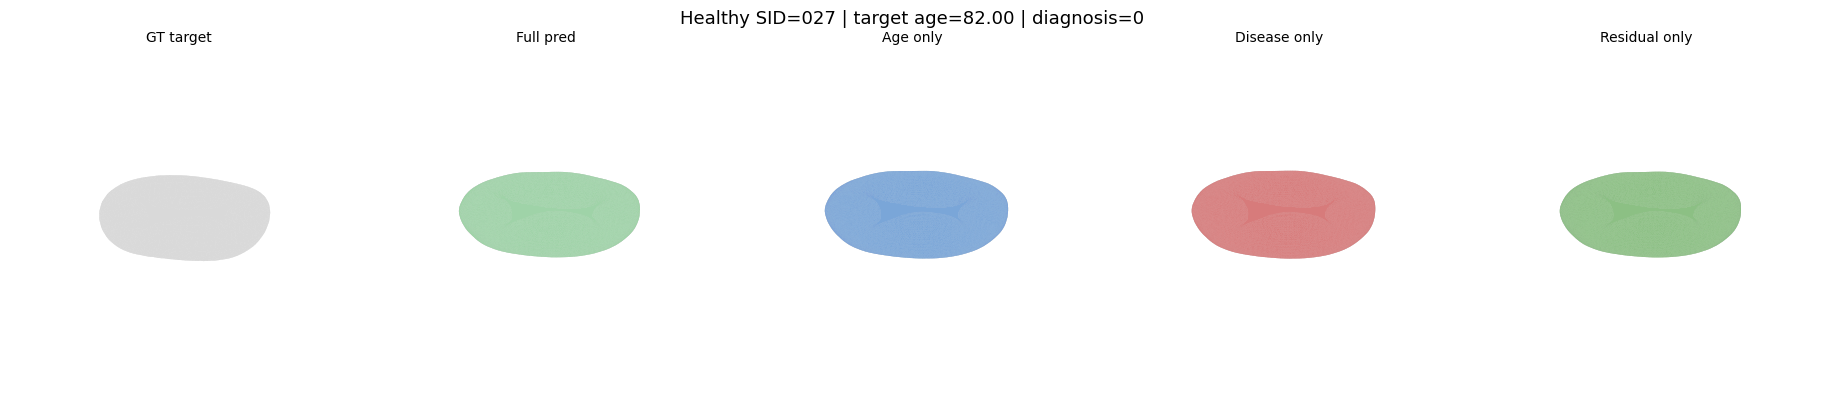

Speed stats: {'total': 0.7859336733818054, 'age': 0.6014553308486938, 'disease_raw': 0.49627625942230225, 'disease': 0.0, 'residual': 0.5059082508087158}
Component norms: {'age': 0.56638103723526, 'disease_raw': 0.4799617528915405, 'disease': 0.0, 'residual': 0.4860808253288269}


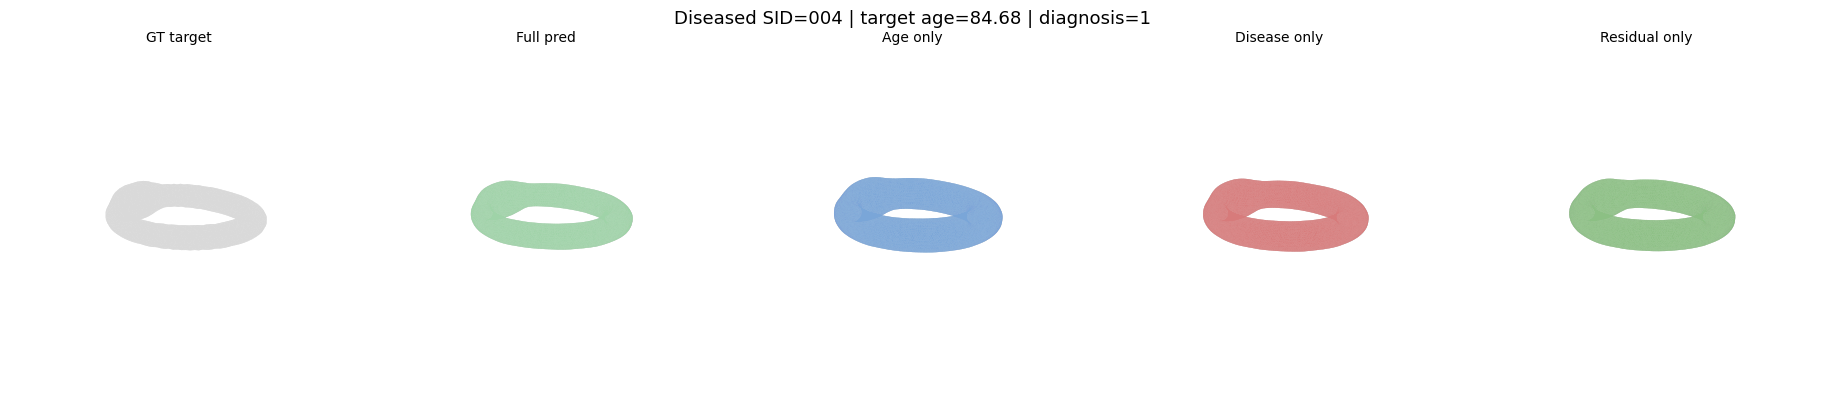

Speed stats: {'total': 1.7302943468093872, 'age': 0.5360834002494812, 'disease_raw': 1.5832349061965942, 'disease': 1.5832349061965942, 'residual': 0.4471019208431244}
Component norms: {'age': 0.522584080696106, 'disease_raw': 1.4074523448944092, 'disease': 1.4074523448944092, 'residual': 0.42316699028015137}


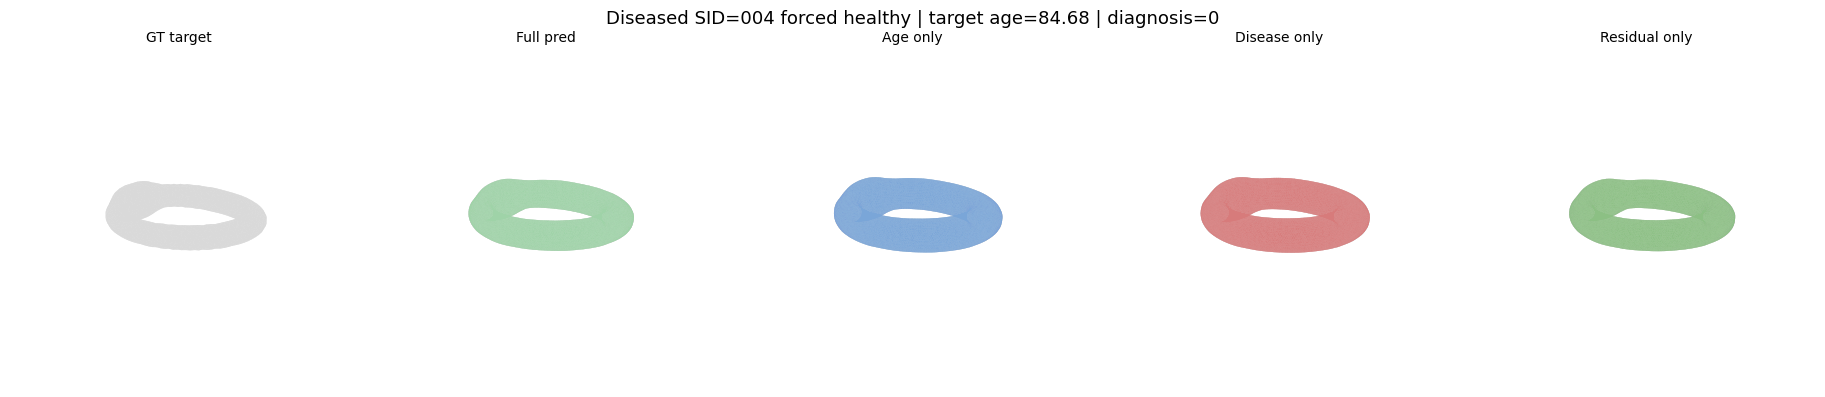

Speed stats: {'total': 0.6958495378494263, 'age': 0.5360834002494812, 'disease_raw': 1.5261088609695435, 'disease': 0.0, 'residual': 0.44364532828330994}
Component norms: {'age': 0.522584080696106, 'disease_raw': 1.4074523448944092, 'disease': 0.0, 'residual': 0.42316699028015137}


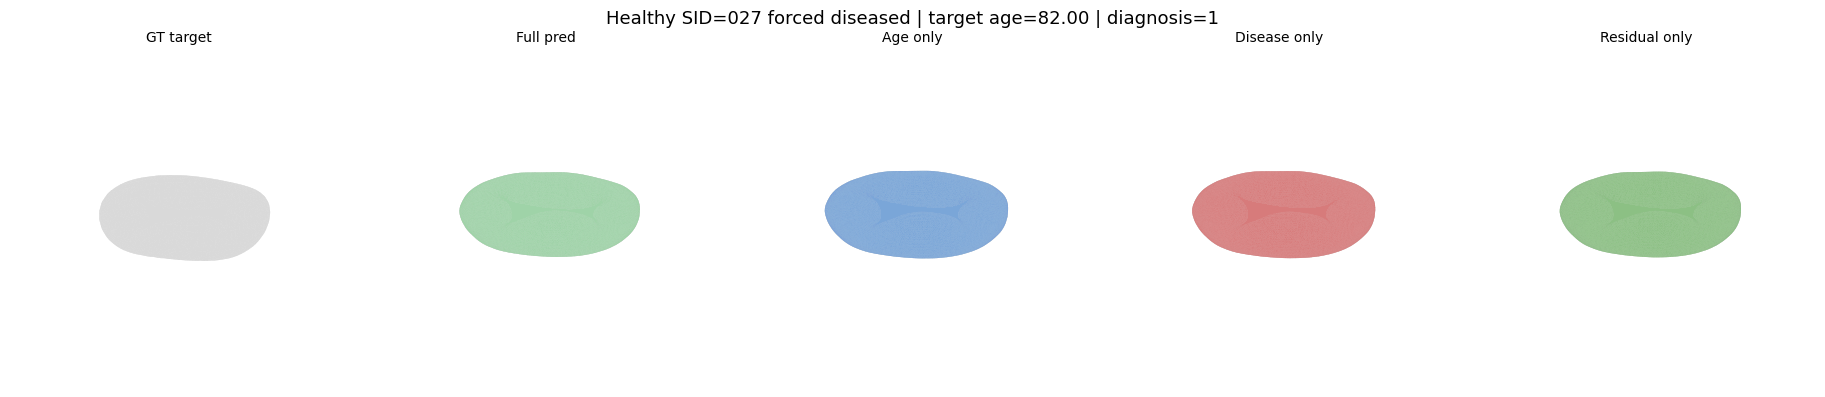

Speed stats: {'total': 0.9694170951843262, 'age': 0.6014553308486938, 'disease_raw': 0.5720130205154419, 'disease': 0.5720130205154419, 'residual': 0.5008214116096497}
Component norms: {'age': 0.56638103723526, 'disease_raw': 0.4799617528915405, 'disease': 0.4799617528915405, 'residual': 0.4860808253288269}


In [8]:
# ---- Component traversals and diagnosis counterfactuals ----

def component_traversal(anchor, records, visit_index=-1, force_diagnosis=None):
    records = sorted(records, key=lambda r: float(r['time']))
    baseline_t = float(records[0]['time'])
    rec_t = records[visit_index]
    cond_t = condition_for_record(rec_t, device=anchor.device, dtype=anchor.dtype)
    if force_diagnosis is not None:
        cond_t = condition_for_diagnosis(force_diagnosis, device=anchor.device, dtype=anchor.dtype)
    dt = float(rec_t['time'] - baseline_t)
    comp, age_full, disease_full, residual_full = disentangled_component_vectors(anchor, baseline_t, float(rec_t['time']), cond_t)
    z_full = anchor + dt * comp['velocity']
    z_age = anchor + dt * age_full
    z_disease = anchor + dt * disease_full
    z_residual = anchor + dt * residual_full
    meshes = {
        'gt': as_mesh(trimesh.load(rec_t['gt_path'], process=False)),
        'full': latent_to_mesh(decoder, z_full, grid_res=GRID_RES_VIS),
        'age': latent_to_mesh(decoder, z_age, grid_res=GRID_RES_VIS),
        'disease': latent_to_mesh(decoder, z_disease, grid_res=GRID_RES_VIS),
        'residual': latent_to_mesh(decoder, z_residual, grid_res=GRID_RES_VIS),
    }
    stats = latent_speed_components(z_full, float(rec_t['time']), cond_t)
    return rec_t, meshes, stats, comp


def show_component_traversal(anchor, records, title_prefix, force_diagnosis=None):
    rec_t, meshes, stats, comp = component_traversal(anchor, records, visit_index=-1, force_diagnosis=force_diagnosis)
    rows = [
        {'mesh': meshes['gt'], 'title': 'GT target'},
        {'mesh': meshes['full'], 'title': 'Full pred'},
        {'mesh': meshes['age'], 'title': 'Age only'},
        {'mesh': meshes['disease'], 'title': 'Disease only'},
        {'mesh': meshes['residual'], 'title': 'Residual only'},
    ]
    plot_mesh_triplets(rows, f"{title_prefix} | target age={rec_t['age']:.2f} | diagnosis={force_diagnosis if force_diagnosis is not None else rec_t['diagnosis']}", colors=['#d9d9d9', '#9fd3a8', '#7aa6d8', '#d77b7b', '#8cc084'])
    print('Speed stats:', stats)
    print('Component norms:', {
        'age': float(torch.norm(comp['age'], dim=1).mean().item()),
        'disease_raw': float(torch.norm(comp['disease_raw'], dim=1).mean().item()),
        'disease': float(torch.norm(comp['disease'], dim=1).mean().item()),
        'residual': float(torch.norm(comp['residual'], dim=1).mean().item()),
    })

show_component_traversal(healthy_cmp['current_anchor'], healthy_cmp['records'], f'Healthy SID={TEST_SID_HEALTHY}')
show_component_traversal(diseased_cmp['current_anchor'], diseased_cmp['records'], f'Diseased SID={TEST_SID_DISEASED}')
show_component_traversal(diseased_cmp['current_anchor'], diseased_cmp['records'], f'Diseased SID={TEST_SID_DISEASED} forced healthy', force_diagnosis=0)
show_component_traversal(healthy_cmp['current_anchor'], healthy_cmp['records'], f'Healthy SID={TEST_SID_HEALTHY} forced diseased', force_diagnosis=1)

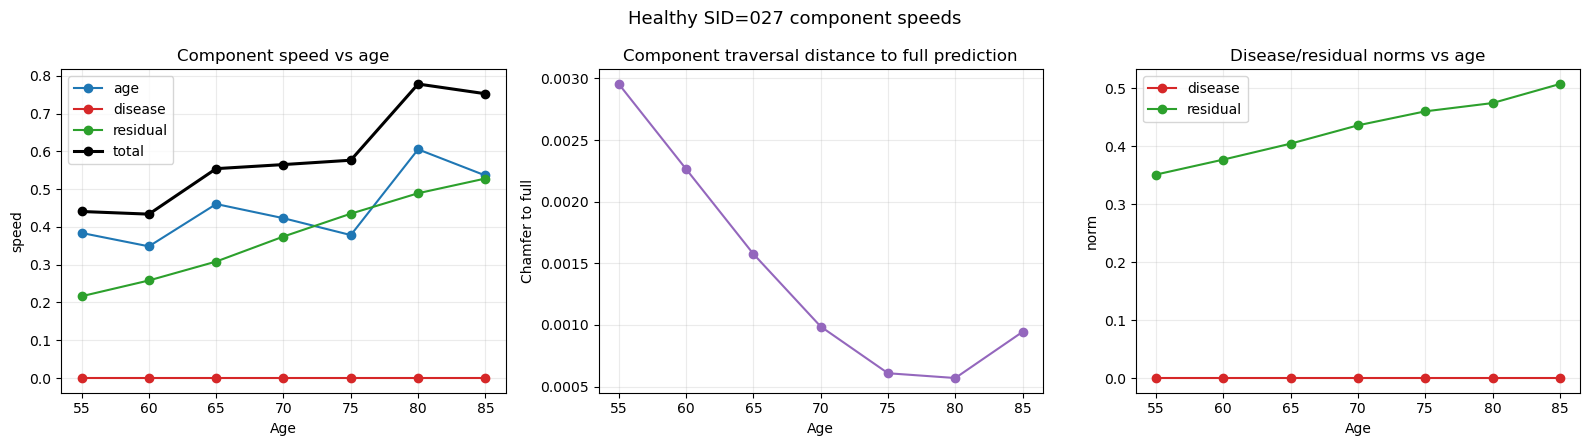

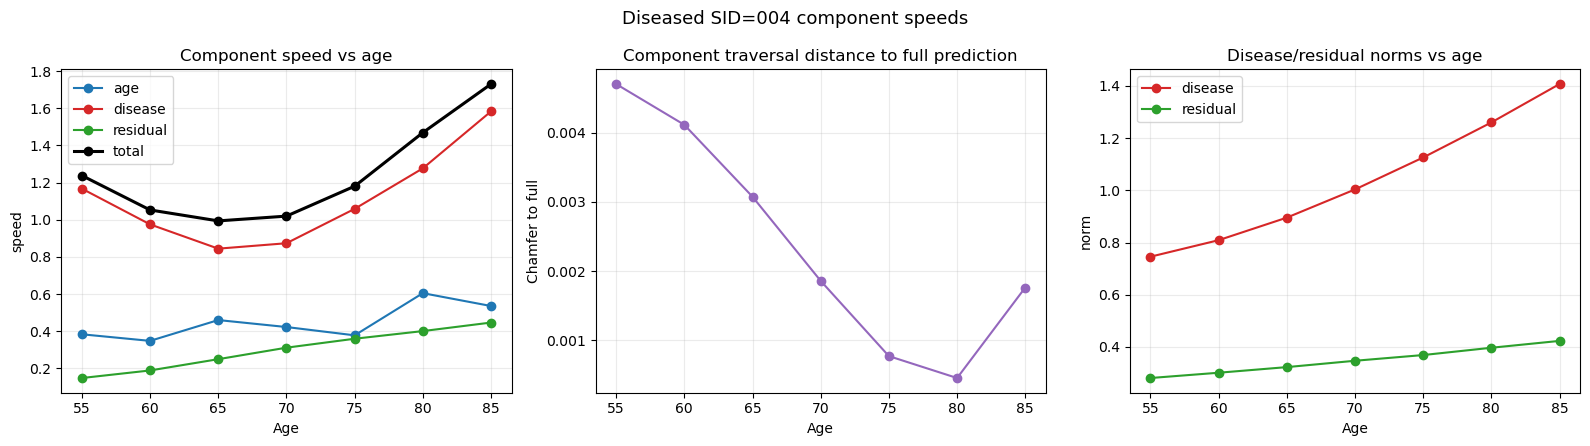

,age_years,time_norm,diagnosis,speed_total,speed_age,speed_disease,speed_residual,disease_norm,residual_norm,chamfer_to_full
0,55.0,0.125000,0,0.440792,0.383980,0.0,0.216464,0.0,0.351250,0.002954
1,60.0,0.250000,0,0.433766,0.348528,0.0,0.258228,0.0,0.377127,0.002264
2,65.0,0.375000,0,0.554207,0.460524,0.0,0.308323,0.0,0.404662,0.001576
3,70.0,0.500000,0,0.564982,0.423003,0.0,0.374530,0.0,0.436261,0.000987
4,75.0,0.625000,0,0.576498,0.378362,0.0,0.434962,0.0,0.460425,0.000609
5,80.0,0.750000,0,0.778156,0.605220,0.0,0.489118,0.0,0.474723,0.000570
6,85.0,0.866973,0,0.752476,0.536083,0.0,0.528048,0.0,0.507585,0.000944


,age_years,time_norm,diagnosis,speed_total,speed_age,speed_disease,speed_residual,disease_norm,residual_norm,chamfer_to_full
0,55.0,0.125000,1,1.237991,0.383980,1.167508,0.148682,0.745715,0.280892,0.004705
1,60.0,0.250000,1,1.052836,0.348528,0.975256,0.189389,0.809031,0.301145,0.004116
2,65.0,0.375000,1,0.994017,0.460524,0.844667,0.250048,0.895444,0.322658,0.003076
3,70.0,0.500000,1,1.019709,0.423003,0.873825,0.311936,1.003438,0.347010,0.001860
4,75.0,0.625000,1,1.180572,0.378362,1.058759,0.360031,1.125966,0.368912,0.000772
5,80.0,0.750000,1,1.468847,0.605220,1.276815,0.401205,1.260252,0.396882,0.000455
6,85.0,0.866973,1,1.730294,0.536083,1.583235,0.447102,1.407452,0.423167,0.001764


In [9]:
# ---- Component speed curves across age ----

def age_to_time_value(age_years):
    a = float(age_years)
    if TIME_KEY.lower() == 'age_norm' and age_slope is not None and abs(age_slope) > 1e-8:
        return (a - float(age_intercept)) / float(age_slope)
    if TIME_KEY.lower() == 'age':
        return a
    return a


def component_speed_curve(anchor, records, diagnosis_override=None, ages=None):
    recs = sorted(records, key=lambda r: float(r['time']))
    baseline_t = float(recs[0]['time'])
    if ages is None:
        ages = np.linspace(float(np.nanmin(LABEL_DF['age'])), float(np.nanmax(LABEL_DF['age'])), 8)
    out = []
    for age in ages:
        t_tar = float(np.clip(age_to_time_value(age), TEST_META['global_min'], TEST_META['global_max']))
        diag = recs[0]['diagnosis'] if diagnosis_override is None else int(diagnosis_override)
        cond_t = condition_for_diagnosis(diag, device=anchor.device, dtype=anchor.dtype)
        z_full = predict_latent_from_anchor(anchor, baseline_t, t_tar, cond_t=cond_t, composed=False)
        speed = latent_speed_components(z_full, t_tar, cond_t)
        comp, age_full, disease_full, residual_full = disentangled_component_vectors(anchor, baseline_t, t_tar, cond_t)
        m_full = latent_to_mesh(decoder, z_full, grid_res=GRID_RES_ANALYSIS)
        m_age = latent_to_mesh(decoder, anchor + (t_tar - baseline_t) * age_full, grid_res=GRID_RES_ANALYSIS)
        out.append({
            'age_years': float(age),
            'time_norm': float(t_tar),
            'diagnosis': diag,
            'speed_total': speed['total'],
            'speed_age': speed['age'],
            'speed_disease': speed['disease'],
            'speed_residual': speed['residual'],
            'disease_norm': float(torch.norm(comp['disease'], dim=1).mean().item()),
            'residual_norm': float(torch.norm(comp['residual'], dim=1).mean().item()),
            'chamfer_to_full': symmetric_chamfer(m_age, m_full, n=4000),
        })
    return pd.DataFrame(out)

ages_eval = np.linspace(55, 85, 7)
curve_h = component_speed_curve(healthy_cmp['current_anchor'], healthy_cmp['records'], diagnosis_override=0, ages=ages_eval)
curve_d = component_speed_curve(diseased_cmp['current_anchor'], diseased_cmp['records'], diagnosis_override=1, ages=ages_eval)
plot_metric_curves(curve_h, f'Healthy SID={TEST_SID_HEALTHY} component speeds')
plot_metric_curves(curve_d, f'Diseased SID={TEST_SID_DISEASED} component speeds')
display(curve_h)
display(curve_d)

In [10]:
# ---- Held-out component extraction for leakage / probe analysis ----

train_anchor_weights = load_train_subject_anchors(EXP_DIR, checkpoint=CHECKPOINT)
train_sid_to_idx = {sid: i for i, sid in enumerate(TRAIN_META['subject_ids_sorted'])}


def extract_train_features(max_subjects=None):
    rows = []
    subject_ids = TRAIN_META['subject_ids_sorted']
    if max_subjects is not None:
        subject_ids = subject_ids[:int(max_subjects)]
    for sid in subject_ids:
        if sid not in train_sid_to_idx:
            continue
        anchor = train_anchor_weights[train_sid_to_idx[sid]].to(DEVICE).view(1, -1)
        recs = TRAIN_META['subject_to_records'][sid]
        baseline_t = float(recs[0]['time'])
        for rec in recs:
            cond_t = condition_for_record(rec, device=anchor.device, dtype=anchor.dtype)
            comp, *_ = disentangled_component_vectors(anchor, baseline_t, float(rec['time']), cond_t)
            rows.append({
                'split': 'train',
                'subject_id': sid,
                'diagnosis': int(rec['diagnosis']),
                'age': float(rec['age']),
                'delta_age': float(rec['time'] - baseline_t),
                'time_index': int(rec.get('tp_user', rec.get('time_index', 0))),
                'bump_height': float(rec.get('bump_height', np.nan)),
                'bump_speed_gt': float(rec.get('bump_speed_gt', np.nan)),
                'age_vec': comp['age'].detach().cpu().numpy().reshape(-1),
                'disease_vec': comp['disease'].detach().cpu().numpy().reshape(-1),
                'residual_vec': comp['residual'].detach().cpu().numpy().reshape(-1),
                'full_vec': comp['velocity'].detach().cpu().numpy().reshape(-1),
            })
    return rows


def extract_test_features(observed_count=1, max_subjects=None):
    rows = []
    subject_ids = TEST_META['subject_ids_sorted']
    if max_subjects is not None:
        subject_ids = subject_ids[:int(max_subjects)]
    for sid in subject_ids:
        recs = TEST_META['subject_to_records'][sid]
        try:
            anchor, _ = fit_anchor(recs, observed_count=observed_count)
        except Exception as e:
            print(f'[warn] test subject {sid} skipped: {e}')
            continue
        baseline_t = float(recs[0]['time'])
        for rec in recs:
            cond_t = condition_for_record(rec, device=anchor.device, dtype=anchor.dtype)
            comp, *_ = disentangled_component_vectors(anchor, baseline_t, float(rec['time']), cond_t)
            rows.append({
                'split': 'test',
                'subject_id': sid,
                'diagnosis': int(rec['diagnosis']),
                'age': float(rec['age']),
                'delta_age': float(rec['time'] - baseline_t),
                'time_index': int(rec.get('tp_user', rec.get('time_index', 0))),
                'bump_height': float(rec.get('bump_height', np.nan)),
                'bump_speed_gt': float(rec.get('bump_speed_gt', np.nan)),
                'age_vec': comp['age'].detach().cpu().numpy().reshape(-1),
                'disease_vec': comp['disease'].detach().cpu().numpy().reshape(-1),
                'residual_vec': comp['residual'].detach().cpu().numpy().reshape(-1),
                'full_vec': comp['velocity'].detach().cpu().numpy().reshape(-1),
            })
    return rows

rows_train = extract_train_features(max_subjects=48)
rows_test = extract_test_features(observed_count=1, max_subjects=12)
print('train feature rows:', len(rows_train), '| test feature rows:', len(rows_test))
FEATURE_ROWS = rows_train + rows_test

train feature rows: 240 | test feature rows: 60


,component,age_r2,age_mae,disease_auc,disease_acc,disease_auc_age_matched
0,age,-0.710282,0.045144,0.753143,0.600000,0.479290
1,disease,-214.177665,0.394372,1.000000,0.700000,1.000000
2,residual,-19.808359,0.169935,0.661714,0.583333,0.662722
3,full,-30702.899633,4.185068,1.000000,0.850000,1.000000


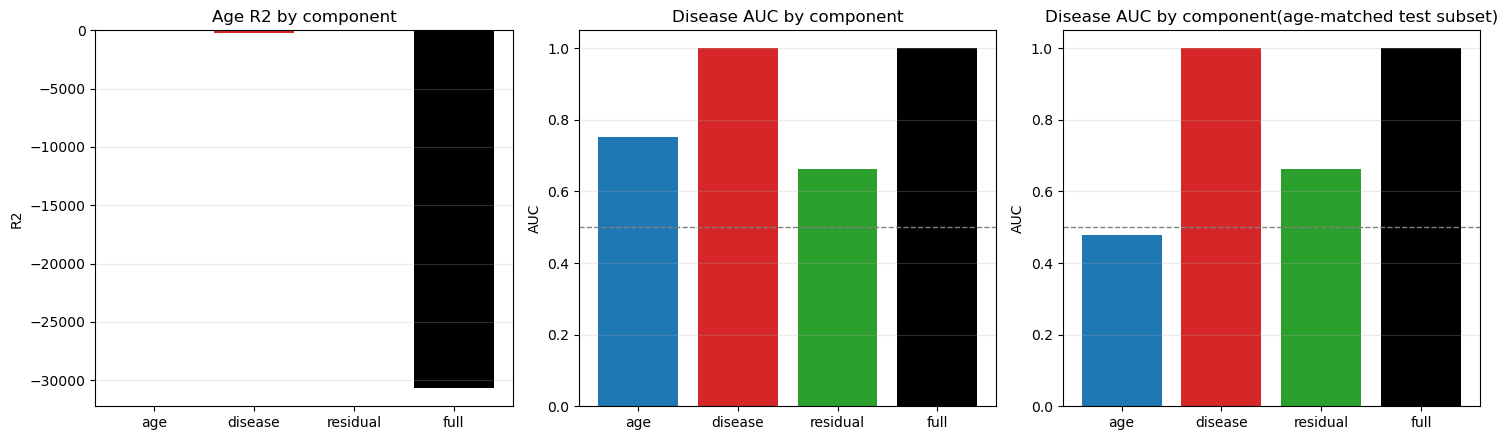

In [11]:
# ---- Leakage matrix and probes ----

def fit_eval_age_probe(train_rows, test_rows, vec_key):
    Xtr = np.stack([r[vec_key] for r in train_rows])
    ytr = np.array([r['delta_age'] for r in train_rows], dtype=float)
    Xte = np.stack([r[vec_key] for r in test_rows])
    yte = np.array([r['delta_age'] for r in test_rows], dtype=float)
    reg = LinearRegression().fit(Xtr, ytr)
    pred = reg.predict(Xte)
    return {
        'r2': float(r2_score(yte, pred)),
        'mae': float(mean_absolute_error(yte, pred)),
    }


def fit_eval_disease_probe(train_rows, test_rows, vec_key):
    Xtr = np.stack([r[vec_key] for r in train_rows])
    ytr = np.array([r['diagnosis'] for r in train_rows], dtype=int)
    Xte = np.stack([r[vec_key] for r in test_rows])
    yte = np.array([r['diagnosis'] for r in test_rows], dtype=int)
    clf = LogisticRegression(max_iter=2000).fit(Xtr, ytr)
    prob = clf.predict_proba(Xte)[:, 1]
    pred = (prob >= 0.5).astype(int)
    return {
        'auc': float(roc_auc_score(yte, prob)) if len(np.unique(yte)) > 1 else np.nan,
        'acc': float(accuracy_score(yte, pred)),
    }


def age_matched_subset(rows, max_per_bin=12, bin_width=2.5):
    df = pd.DataFrame([{k: r[k] for k in ['split','subject_id','diagnosis','age','delta_age']} for r in rows])
    df['bin'] = (df['age'] / float(bin_width)).round().astype(int)
    keep_idx = []
    for b, g in df.groupby('bin'):
        g0 = g[g['diagnosis'] == 0].index.tolist()
        g1 = g[g['diagnosis'] == 1].index.tolist()
        take = min(len(g0), len(g1), int(max_per_bin))
        keep_idx.extend(g0[:take])
        keep_idx.extend(g1[:take])
    keep_idx = sorted(set(int(i) for i in keep_idx))
    return [rows[i] for i in keep_idx]

train_probe = [r for r in FEATURE_ROWS if r['split'] == 'train']
test_probe = [r for r in FEATURE_ROWS if r['split'] == 'test']
matched_test_probe = age_matched_subset(test_probe)

vec_keys = ['age_vec', 'disease_vec', 'residual_vec', 'full_vec']
name_map = {
    'age_vec': 'age',
    'disease_vec': 'disease',
    'residual_vec': 'residual',
    'full_vec': 'full',
}
probe_rows = []
for vk in vec_keys:
    age_stats = fit_eval_age_probe(train_probe, test_probe, vk)
    dis_stats = fit_eval_disease_probe(train_probe, test_probe, vk)
    dis_matched = fit_eval_disease_probe(train_probe, matched_test_probe, vk) if matched_test_probe else {'auc': np.nan, 'acc': np.nan}
    probe_rows.append({
        'component': name_map[vk],
        'age_r2': age_stats['r2'],
        'age_mae': age_stats['mae'],
        'disease_auc': dis_stats['auc'],
        'disease_acc': dis_stats['acc'],
        'disease_auc_age_matched': dis_matched['auc'],
    })
PROBE_DF = pd.DataFrame(probe_rows)
display(PROBE_DF)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
axes[0].bar(PROBE_DF['component'], PROBE_DF['age_r2'], color=['tab:blue','tab:red','tab:green','black'])
axes[0].set_title('Age R2 by component')
axes[0].set_ylabel('R2')
axes[0].grid(axis='y', alpha=0.25)

axes[1].bar(PROBE_DF['component'], PROBE_DF['disease_auc'], color=['tab:blue','tab:red','tab:green','black'])
axes[1].axhline(0.5, color='gray', linestyle='--', linewidth=1)
axes[1].set_title('Disease AUC by component')
axes[1].set_ylabel('AUC')
axes[1].grid(axis='y', alpha=0.25)

axes[2].bar(PROBE_DF['component'], PROBE_DF['disease_auc_age_matched'], color=['tab:blue','tab:red','tab:green','black'])
axes[2].axhline(0.5, color='gray', linestyle='--', linewidth=1)
axes[2].set_title('Disease AUC by component(age-matched test subset)')
axes[2].set_ylabel('AUC')
axes[2].grid(axis='y', alpha=0.25)
plt.tight_layout()
plt.show()

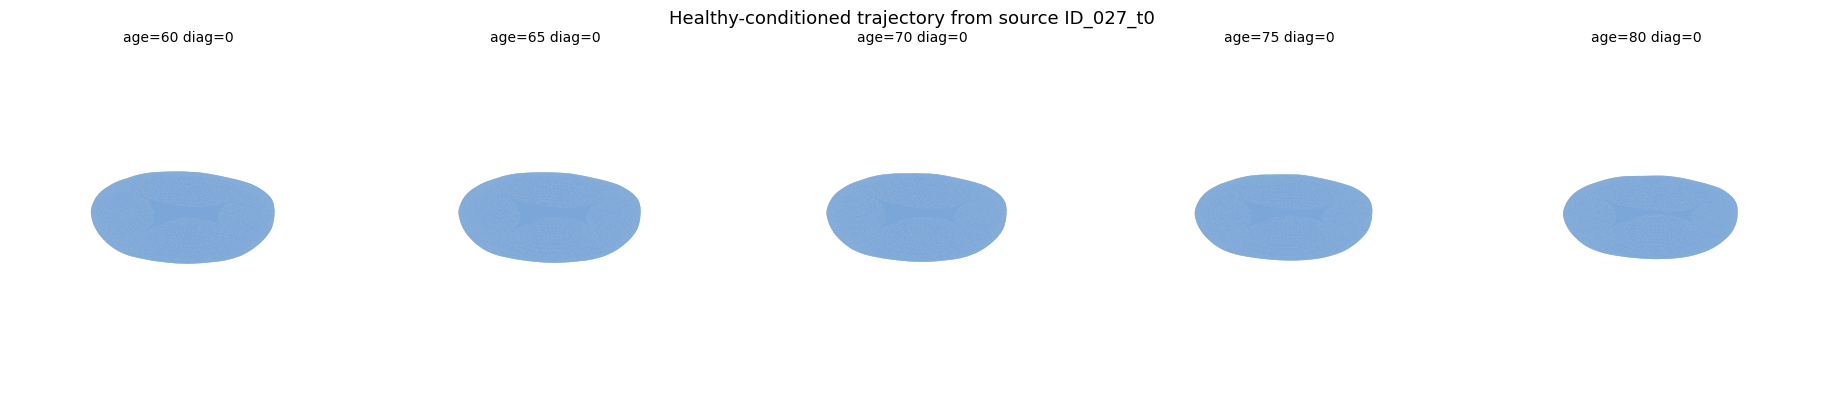

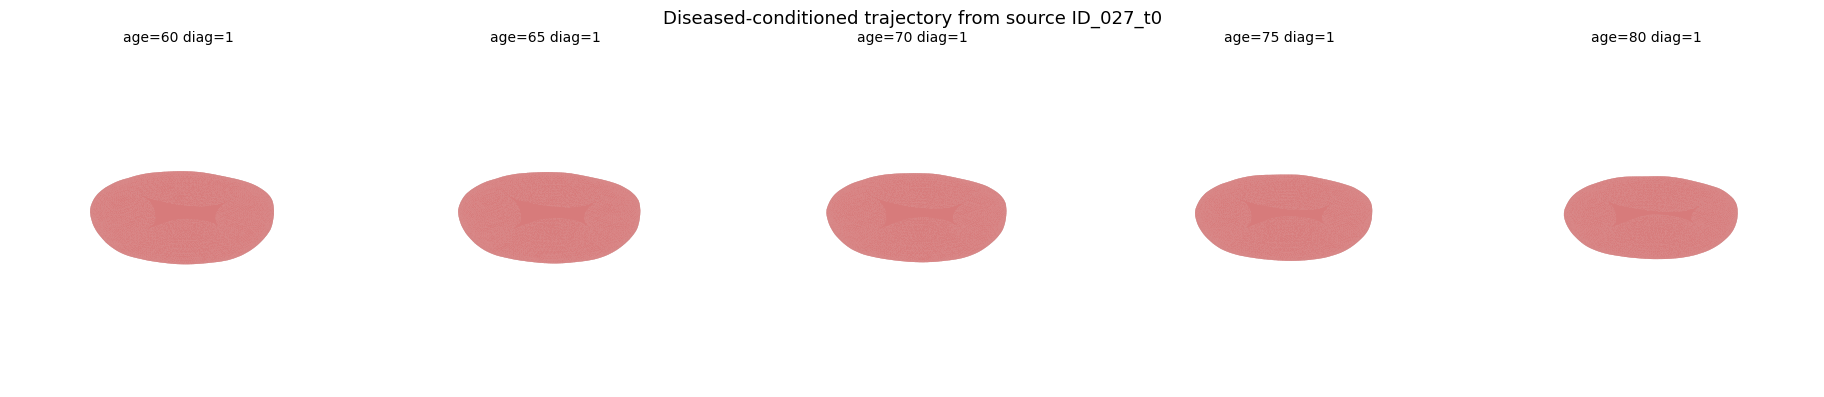

In [12]:
# ---- Counterfactual diagnosis trajectories from the same fitted subject ----

def counterfactual_trajectory(anchor, source_record, diagnosis_values=(0,1), age_years=None):
    if age_years is None:
        age_years = np.arange(55, 86, 5)
    baseline_t = float(source_record['time'])
    out = []
    for d in diagnosis_values:
        rows = []
        for age in age_years:
            t_tar = float(np.clip(age_to_time_value(age), TEST_META['global_min'], TEST_META['global_max']))
            cond_t = condition_for_diagnosis(int(d), device=anchor.device, dtype=anchor.dtype)
            z_t = predict_latent_from_anchor(anchor, baseline_t, t_tar, cond_t=cond_t, composed=False)
            rows.append({
                'mesh': latent_to_mesh(decoder, z_t, grid_res=GRID_RES_ANALYSIS),
                'title': f'age={age:.0f} diag={int(d)}',
                'age': age,
                'diagnosis': int(d),
            })
        out.append(rows)
    return out

source_rec = healthy_cmp['records'][0]
cf_rows_h, cf_rows_d = counterfactual_trajectory(healthy_cmp['current_anchor'], source_rec, diagnosis_values=(0,1), age_years=np.arange(60, 86, 5))
plot_mesh_triplets(cf_rows_h[:5], f'Healthy-conditioned trajectory from source {source_rec["name"]}', colors=['#7aa6d8'] * min(5, len(cf_rows_h[:5])))
plot_mesh_triplets(cf_rows_d[:5], f'Diseased-conditioned trajectory from source {source_rec["name"]}', colors=['#d77b7b'] * min(5, len(cf_rows_d[:5])))

Current log keys sample: ['epoch', 'latent_magnitude', 'learning_rate', 'loss', 'param_magnitude', 'timing']
[info] no keys for Current experiment: reconstruction / pair / cocycle losses: ['rec', 'recon', 'pair', 'cyc', 'cocycle']
[info] no keys for Current experiment: disentanglement / regularization losses: ['dis', 'res', 'adv', 'leak', 'zero', 'code', 'eik']


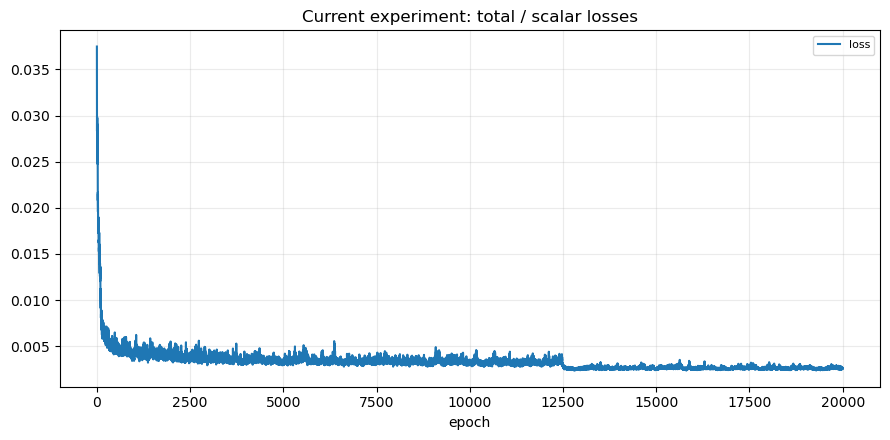

[info] no keys for Baseline experiment: reconstruction / pair / cocycle losses: ['rec', 'recon', 'pair', 'cyc', 'cocycle']


[]

In [13]:
# ---- Training dynamics from Logs.pth ----

def load_logs(log_path):
    if not Path(log_path).exists():
        print(f'[warn] missing logs: {log_path}')
        return None
    return torch.load(log_path, map_location='cpu')


def candidate_log_keys(logs, patterns):
    keys = []
    for k, v in logs.items():
        if not isinstance(v, list) or len(v) == 0:
            continue
        name = str(k).lower()
        if any(p in name for p in patterns):
            try:
                float(v[-1])
            except Exception:
                continue
            keys.append(k)
    return sorted(set(keys))


def plot_log_group(logs, title, patterns, max_keys=10):
    if logs is None:
        return []
    keys = candidate_log_keys(logs, patterns)[:max_keys]
    if not keys:
        print(f'[info] no keys for {title}: {patterns}')
        return []
    plt.figure(figsize=(9, 4.5))
    for k in keys:
        vals = np.asarray(logs[k], dtype=float)
        plt.plot(np.arange(1, len(vals) + 1), vals, label=k)
    plt.title(title)
    plt.xlabel('epoch')
    plt.grid(alpha=0.25)
    plt.legend(fontsize=8, ncol=2)
    plt.tight_layout()
    plt.show()
    return keys

logs_cur = load_logs(EXP_DIR / 'Logs.pth')
logs_base = load_logs(BASELINE_EXP_DIR / 'Logs.pth')

print('Current log keys sample:', sorted(list(logs_cur.keys()))[:20] if logs_cur else None)
plot_log_group(logs_cur, 'Current experiment: reconstruction / pair / cocycle losses', ['rec', 'recon', 'pair', 'cyc', 'cocycle'])
plot_log_group(logs_cur, 'Current experiment: disentanglement / regularization losses', ['dis', 'res', 'adv', 'leak', 'zero', 'code', 'eik'])
plot_log_group(logs_cur, 'Current experiment: total / scalar losses', ['loss'])
plot_log_group(logs_base, 'Baseline experiment: reconstruction / pair / cocycle losses', ['rec', 'recon', 'pair', 'cyc', 'cocycle'])


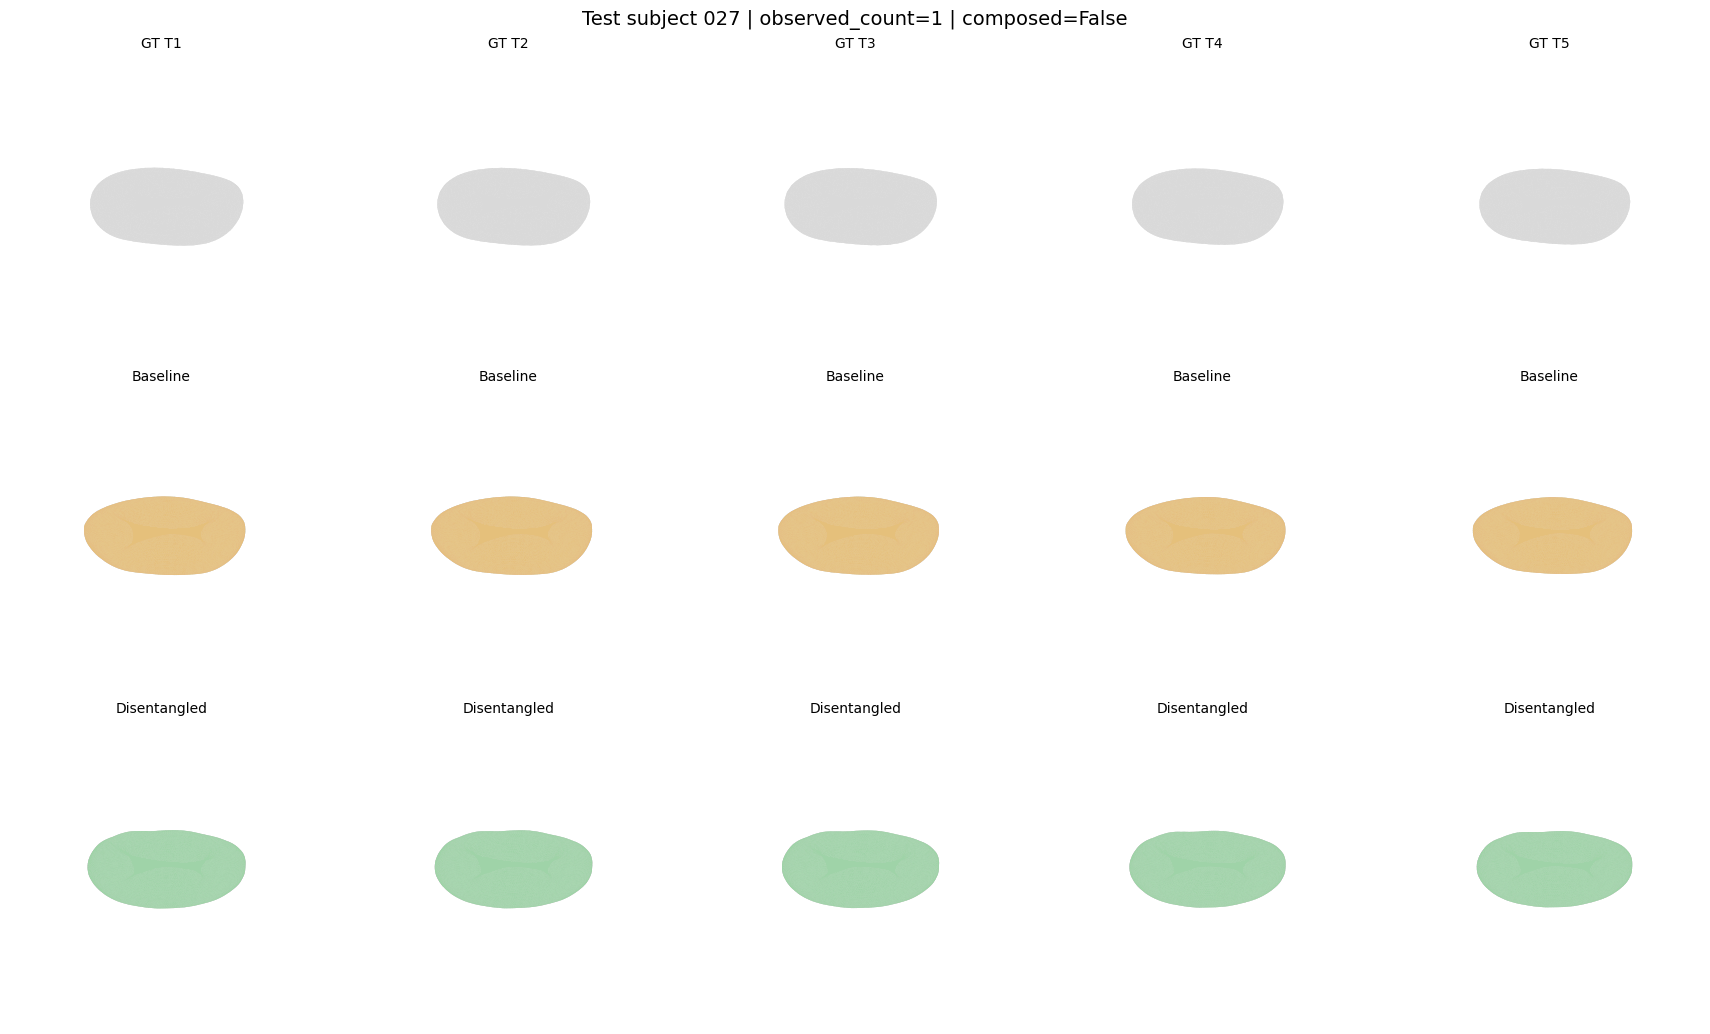

,tp_user,age,diagnosis,baseline_chamfer,disentangled_chamfer
0,1,77.962471,0,0.001771,0.001570
1,2,78.649971,0,0.001739,0.001568
2,3,79.368477,0,0.001787,0.001599
3,4,81.046677,0,0.001788,0.001602
4,5,81.998978,0,0.001816,0.001613


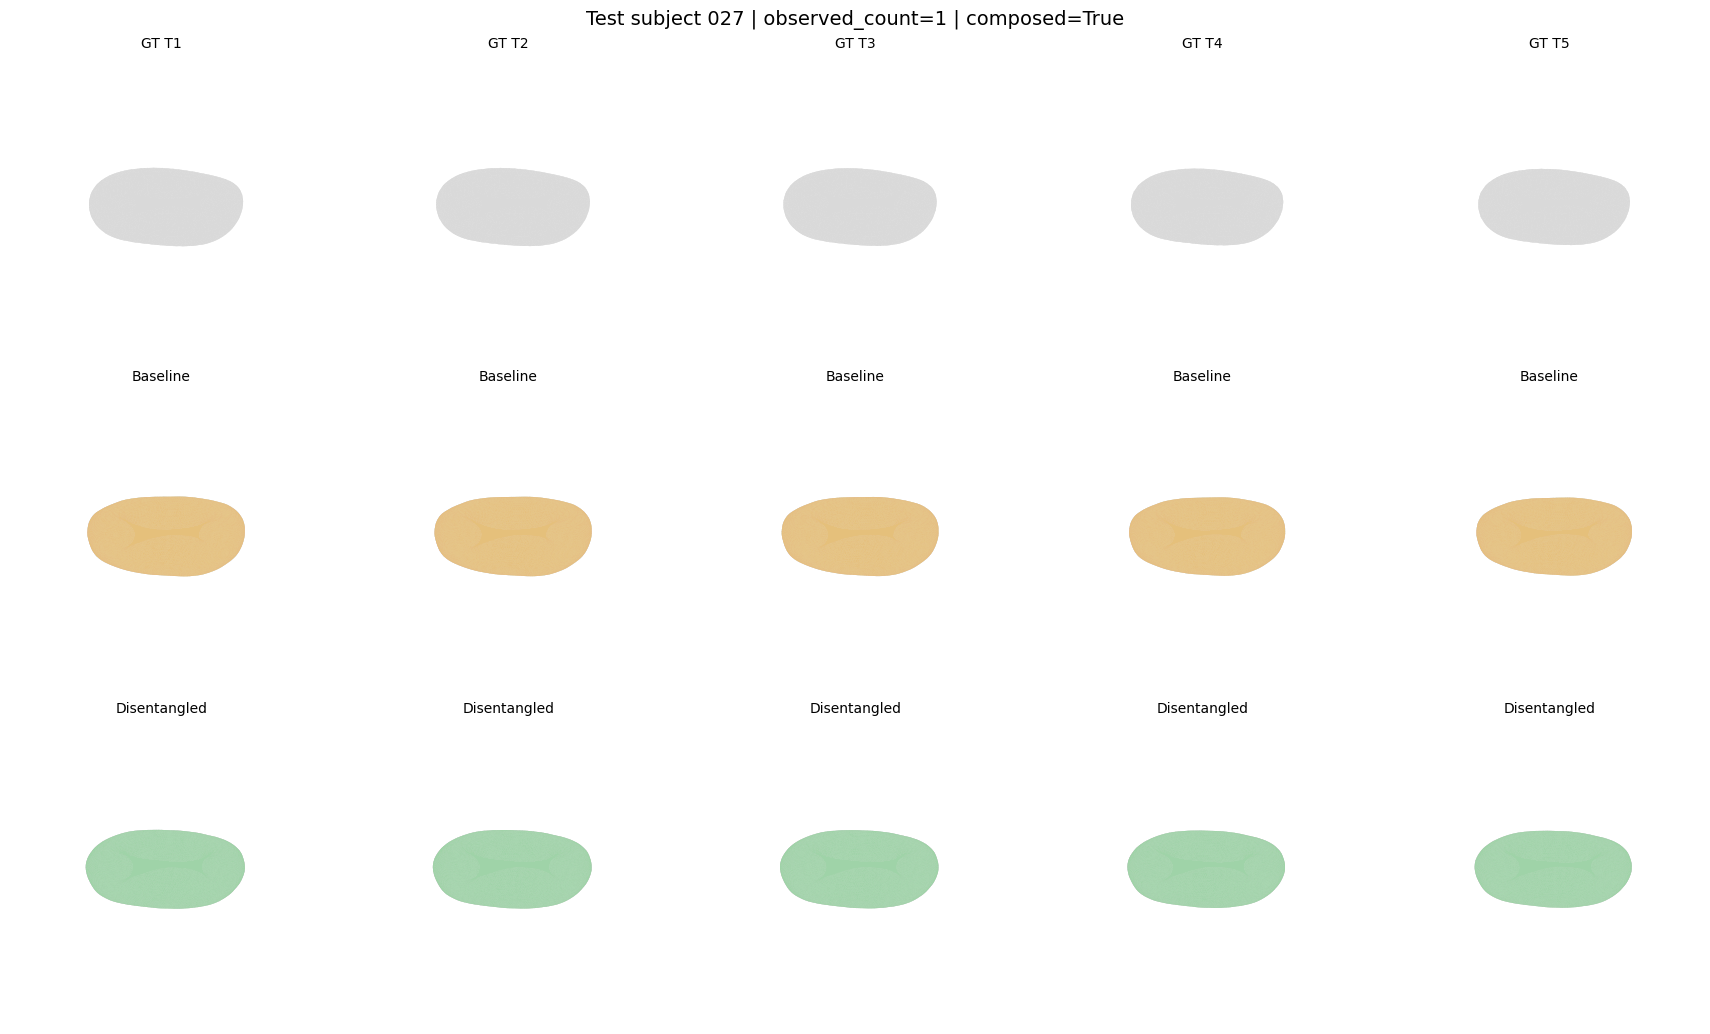

,tp_user,age,diagnosis,baseline_chamfer,disentangled_chamfer
0,1,77.962471,0,0.001607,0.001595
1,2,78.649971,0,0.001595,0.001643
2,3,79.368477,0,0.001613,0.001652
3,4,81.046677,0,0.001579,0.001659
4,5,81.998978,0,0.001581,0.001659


model              baseline           disentangled          
rollout            composed    direct     composed    direct
tp_user age                                                 
1       77.962471  0.001607  0.001771     0.001595  0.001570
2       78.649971  0.001595  0.001739     0.001643  0.001568
3       79.368477  0.001613  0.001787     0.001652  0.001599
4       81.046677  0.001579  0.001788     0.001659  0.001602
5       81.998978  0.001581  0.001816     0.001659  0.001613

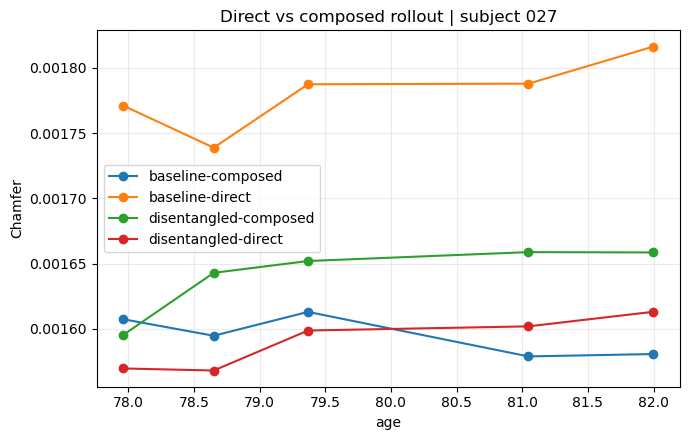

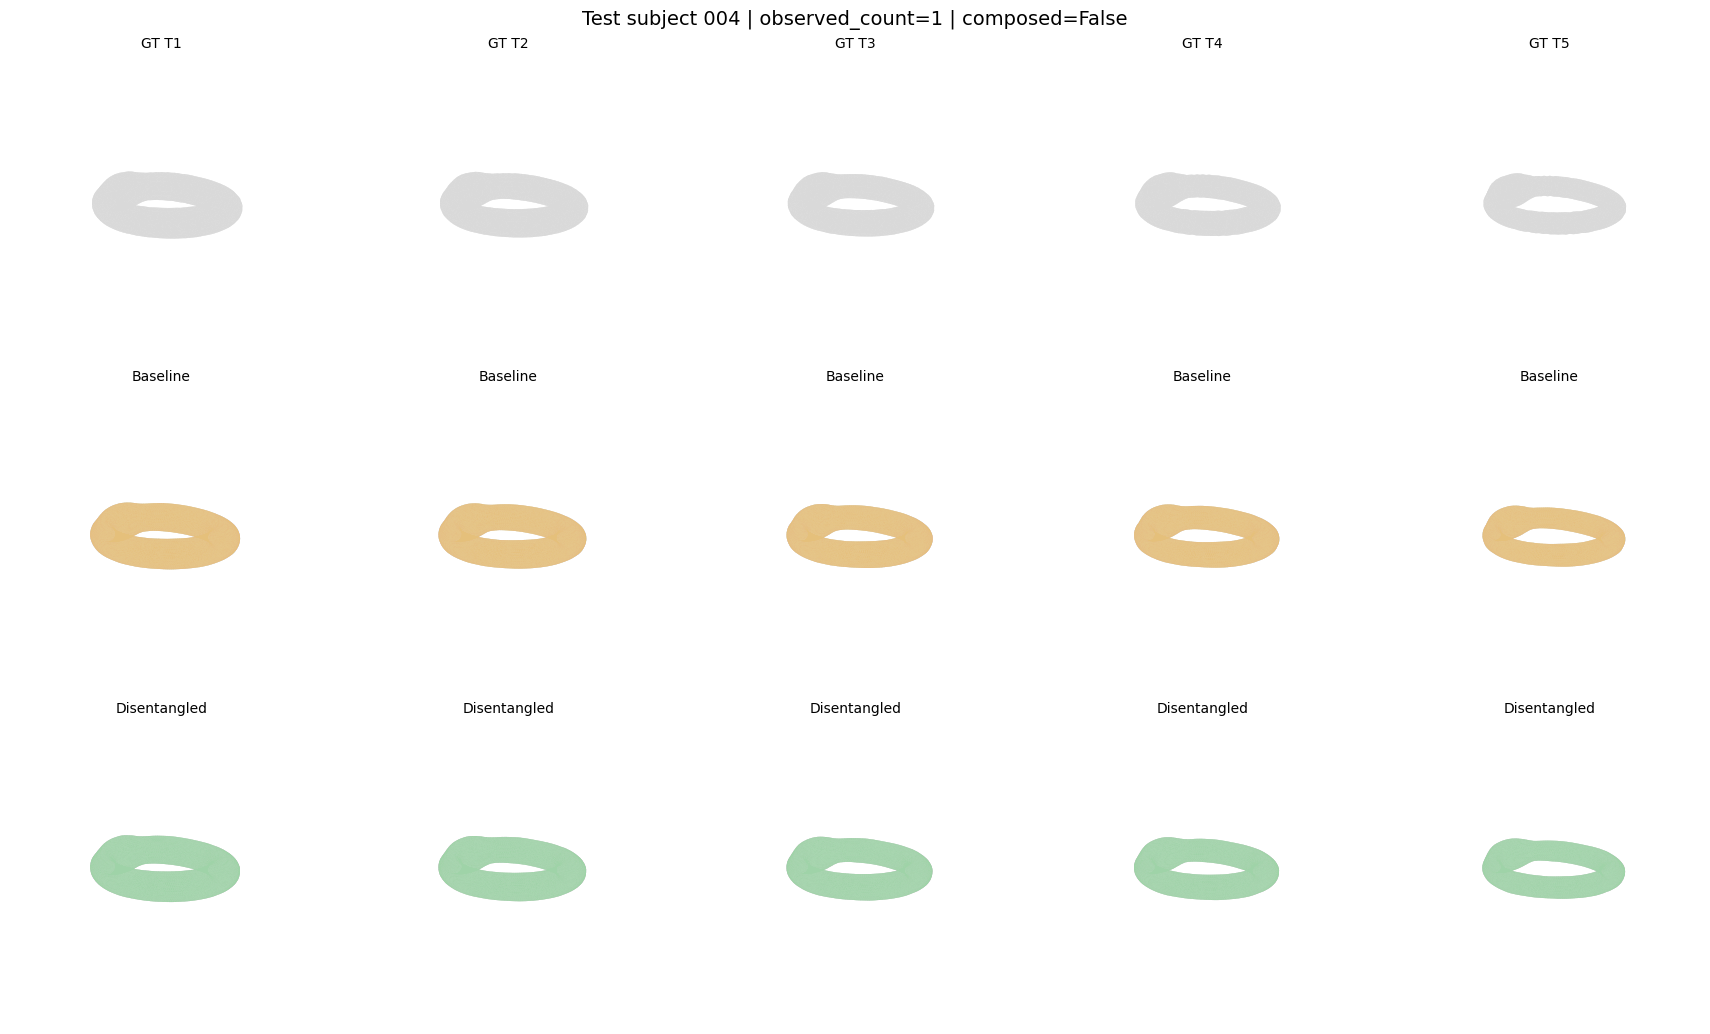

,tp_user,age,diagnosis,baseline_chamfer,disentangled_chamfer
0,1,78.753929,1,0.000722,0.000742
1,2,80.586525,1,0.000593,0.000632
2,3,82.017929,1,0.000513,0.000547
3,4,82.758339,1,0.000473,0.000513
4,5,84.678932,1,0.000398,0.000432


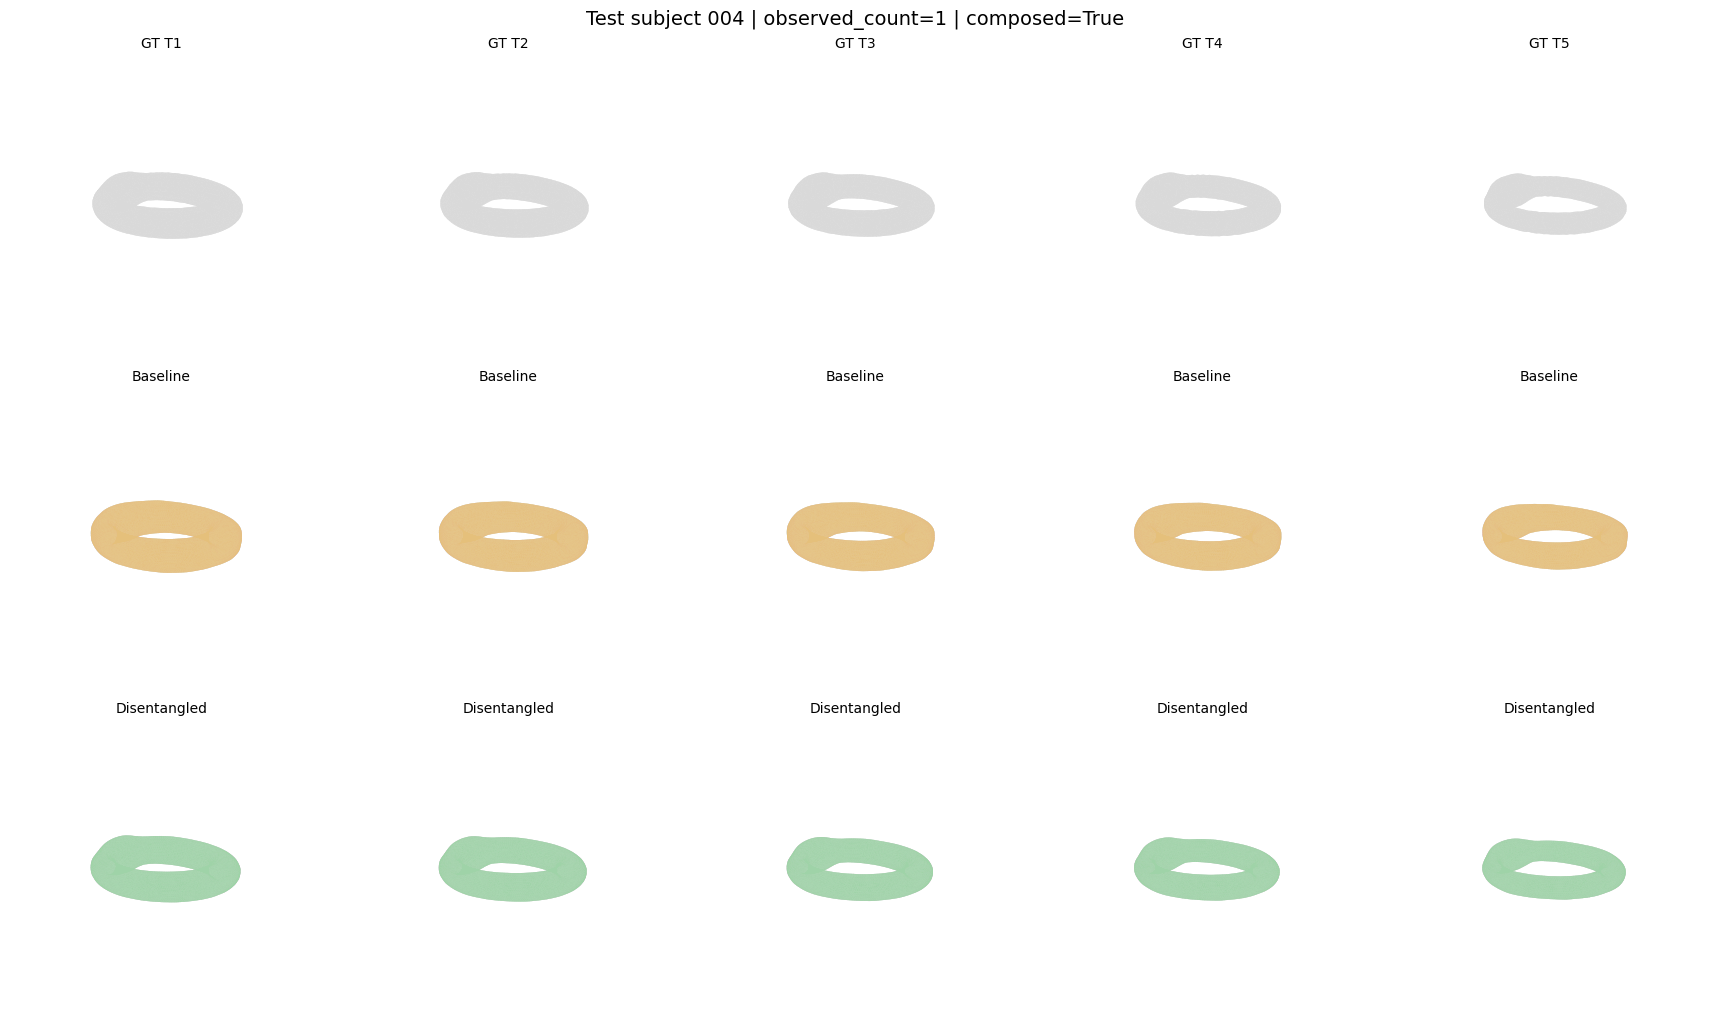

,tp_user,age,diagnosis,baseline_chamfer,disentangled_chamfer
0,1,78.753929,1,0.001039,0.000728
1,2,80.586525,1,0.001077,0.000623
2,3,82.017929,1,0.001108,0.000550
3,4,82.758339,1,0.001157,0.000519
4,5,84.678932,1,0.001245,0.000478


model              baseline           disentangled          
rollout            composed    direct     composed    direct
tp_user age                                                 
1       78.753929  0.001039  0.000722     0.000728  0.000742
2       80.586525  0.001077  0.000593     0.000623  0.000632
3       82.017929  0.001108  0.000513     0.000550  0.000547
4       82.758339  0.001157  0.000473     0.000519  0.000513
5       84.678932  0.001245  0.000398     0.000478  0.000432

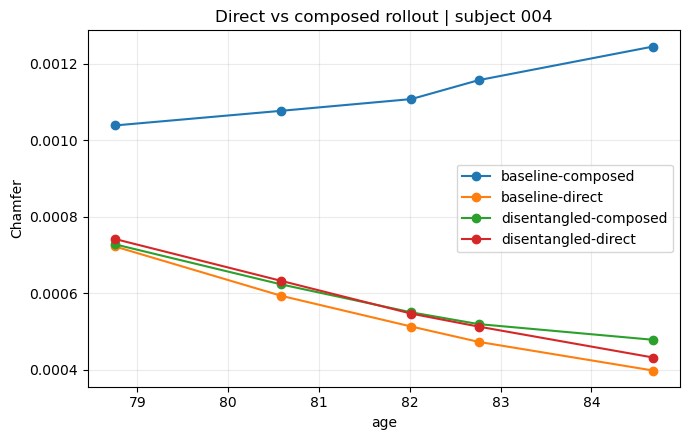

In [14]:
# ---- Direct vs composed rollout accuracy ----

def compare_direct_vs_composed(sid, observed_count=1):
    direct = compare_subject(sid, observed_count=observed_count, composed=False)
    composed = compare_subject(sid, observed_count=observed_count, composed=True)
    rows = []
    for kind, cmp_dict in [('direct', direct), ('composed', composed)]:
        for rr in cmp_dict['current_rows']:
            rows.append({
                'subject_id': sid,
                'model': 'disentangled',
                'rollout': kind,
                'tp_user': rr['record']['tp_user'],
                'age': rr['record']['age'],
                'chamfer': rr['chamfer'],
            })
        for rr in cmp_dict['baseline_rows']:
            rows.append({
                'subject_id': sid,
                'model': 'baseline',
                'rollout': kind,
                'tp_user': rr['record']['tp_user'],
                'age': rr['record']['age'],
                'chamfer': rr['chamfer'],
            })
    df = pd.DataFrame(rows)
    display(df.pivot_table(index=['tp_user', 'age'], columns=['model', 'rollout'], values='chamfer'))
    fig, ax = plt.subplots(figsize=(7, 4.5))
    for (model, rollout), g in df.groupby(['model', 'rollout']):
        g = g.sort_values('age')
        ax.plot(g['age'], g['chamfer'], marker='o', label=f'{model}-{rollout}')
    ax.set_title(f'Direct vs composed rollout | subject {sid}')
    ax.set_xlabel('age')
    ax.set_ylabel('Chamfer')
    ax.grid(alpha=0.25)
    ax.legend()
    plt.tight_layout()
    plt.show()
    return df

rollout_df_healthy = compare_direct_vs_composed(TEST_SID_HEALTHY, observed_count=1)
rollout_df_diseased = compare_direct_vs_composed(TEST_SID_DISEASED, observed_count=1)


,split,subject_id,diagnosis,age,delta_age,time_index,bump_height,bump_speed_gt,age_norm,disease_norm,residual_norm,full_norm
0,train,000,1,77.595505,0.000000,1,NaN,NaN,0.510658,1.316296,0.395019,1.466099
1,train,000,1,79.049309,0.036345,2,NaN,NaN,0.543971,1.366965,0.406150,1.526256
2,train,000,1,80.678406,0.077073,3,NaN,NaN,0.560811,1.423838,0.418557,1.586509
3,train,000,1,81.951141,0.108891,4,NaN,NaN,0.556721,1.468410,0.428278,1.627756
4,train,000,1,83.689980,0.152362,5,NaN,NaN,0.526712,1.529454,0.441621,1.676808


/tmp/ipykernel_3248926/2033096193.py:26: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([data0, data1], labels=['healthy', 'diseased'])
/tmp/ipykernel_3248926/2033096193.py:26: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([data0, data1], labels=['healthy', 'diseased'])
/tmp/ipykernel_3248926/2033096193.py:26: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([data0, data1], labels=['healthy', 'diseased'])
/tmp/ipykernel_3248926/2033096193.py:26: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name wi

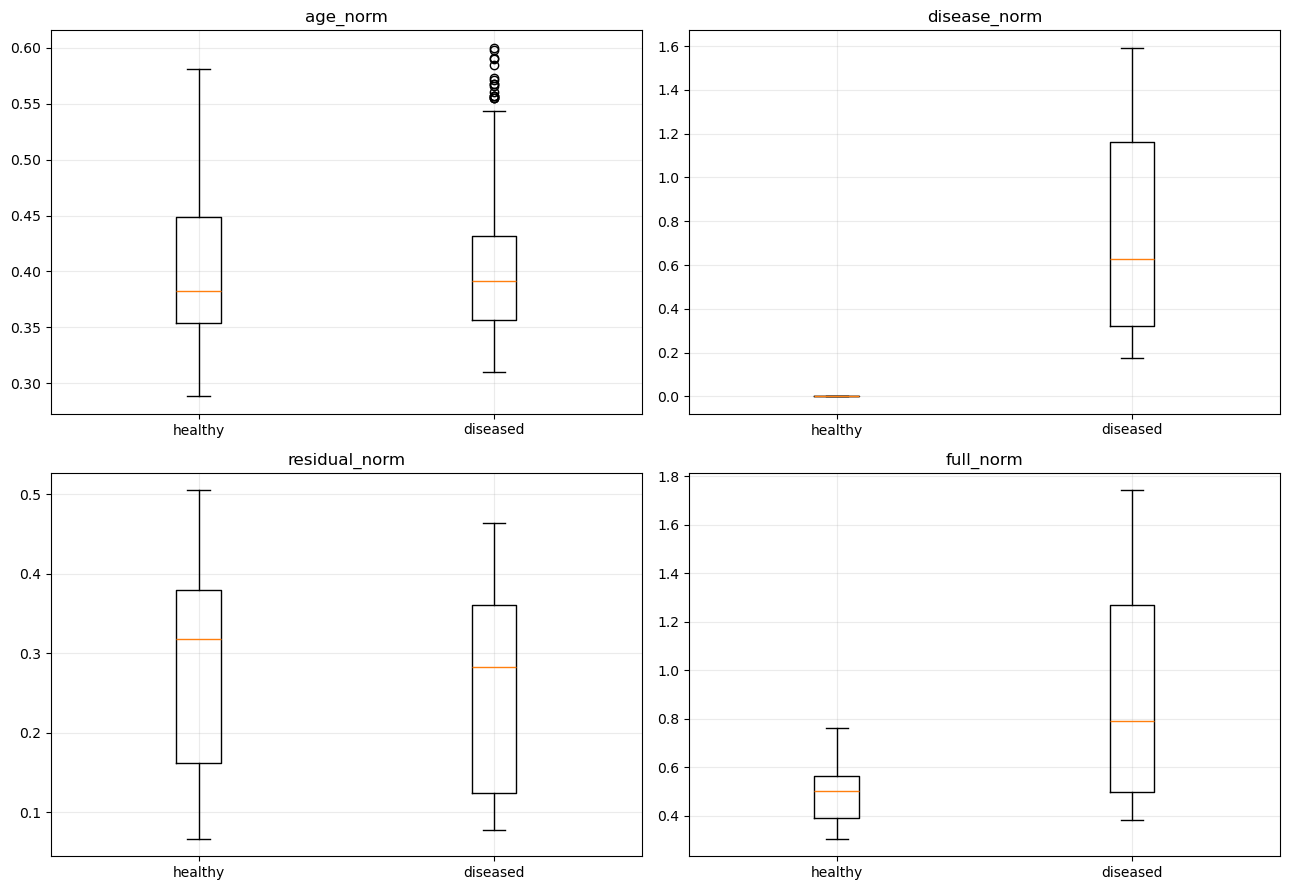

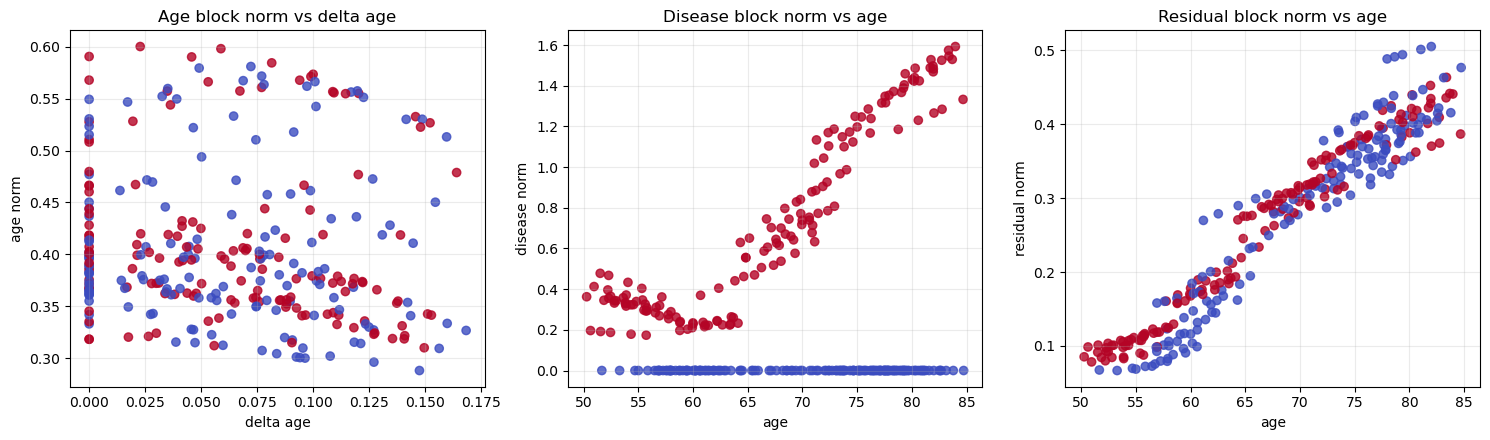

In [15]:
# ---- Component norm statistics and synthetic GT correlations ----

FEAT_DF = pd.DataFrame([
    {
        'split': r['split'],
        'subject_id': r['subject_id'],
        'diagnosis': r['diagnosis'],
        'age': r['age'],
        'delta_age': r['delta_age'],
        'time_index': r.get('time_index', np.nan),
        'bump_height': r.get('bump_height', np.nan),
        'bump_speed_gt': r.get('bump_speed_gt', np.nan),
        'age_norm': float(np.linalg.norm(r['age_vec'])),
        'disease_norm': float(np.linalg.norm(r['disease_vec'])),
        'residual_norm': float(np.linalg.norm(r['residual_vec'])),
        'full_norm': float(np.linalg.norm(r['full_vec'])),
    }
    for r in FEATURE_ROWS
])
display(FEAT_DF.head())

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for ax, col in zip(axes.ravel(), ['age_norm', 'disease_norm', 'residual_norm', 'full_norm']):
    data0 = FEAT_DF.loc[FEAT_DF['diagnosis'] == 0, col].dropna().values
    data1 = FEAT_DF.loc[FEAT_DF['diagnosis'] == 1, col].dropna().values
    ax.boxplot([data0, data1], labels=['healthy', 'diseased'])
    ax.set_title(col)
    ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
axes[0].scatter(FEAT_DF['delta_age'], FEAT_DF['age_norm'], c=FEAT_DF['diagnosis'], cmap='coolwarm', alpha=0.8)
axes[0].set_title('Age block norm vs delta age')
axes[0].set_xlabel('delta age')
axes[0].set_ylabel('age norm')
axes[0].grid(alpha=0.25)

axes[1].scatter(FEAT_DF['age'], FEAT_DF['disease_norm'], c=FEAT_DF['diagnosis'], cmap='coolwarm', alpha=0.8)
axes[1].set_title('Disease block norm vs age')
axes[1].set_xlabel('age')
axes[1].set_ylabel('disease norm')
axes[1].grid(alpha=0.25)

axes[2].scatter(FEAT_DF['age'], FEAT_DF['residual_norm'], c=FEAT_DF['diagnosis'], cmap='coolwarm', alpha=0.8)
axes[2].set_title('Residual block norm vs age')
axes[2].set_xlabel('age')
axes[2].set_ylabel('residual norm')
axes[2].grid(alpha=0.25)
plt.tight_layout()
plt.show()

if FEAT_DF['bump_speed_gt'].notna().any():
    corr_rows = []
    for col in ['age_norm', 'disease_norm', 'residual_norm', 'full_norm']:
        sub = FEAT_DF[['bump_speed_gt', 'bump_height', col]].dropna()
        if len(sub) < 3:
            continue
        corr_speed = float(np.corrcoef(sub['bump_speed_gt'], sub[col])[0, 1])
        corr_height = float(np.corrcoef(sub['bump_height'], sub[col])[0, 1])
        corr_rows.append({'component': col, 'corr_bump_speed_gt': corr_speed, 'corr_bump_height': corr_height})
    CORR_DF = pd.DataFrame(corr_rows)
    display(CORR_DF)
    fig, ax = plt.subplots(figsize=(7, 4.5))
    ax.bar(CORR_DF['component'], CORR_DF['corr_bump_speed_gt'], color='tab:purple')
    ax.set_title('Correlation with synthetic bump speed ground truth')
    ax.set_ylabel('Pearson r')
    ax.grid(axis='y', alpha=0.25)
    plt.tight_layout()
    plt.show()
else:
    CORR_DF = pd.DataFrame()


In [ ]:
# ---- Export summary ----

OUT_DIR = EXP_DIR / 'analysis_velocity_disentanglement_64_128_64_binary_margin_adv'
OUT_DIR.mkdir(parents=True, exist_ok=True)
probe_csv = OUT_DIR / 'probe_metrics.csv'
curve_h_csv = OUT_DIR / 'speed_curve_healthy.csv'
curve_d_csv = OUT_DIR / 'speed_curve_diseased.csv'
summary_json = OUT_DIR / 'summary.json'

PROBE_DF.to_csv(probe_csv, index=False)
curve_h.to_csv(curve_h_csv, index=False)
curve_d.to_csv(curve_d_csv, index=False)

summary = {
    'experiment_dir': str(EXP_DIR),
    'baseline_experiment_dir': str(BASELINE_EXP_DIR),
    'checkpoint': CHECKPOINT,
    'baseline_checkpoint': BASELINE_CHECKPOINT,
    'healthy_sid': str(TEST_SID_HEALTHY),
    'diseased_sid': str(TEST_SID_DISEASED),
    'train_probe_rows': int(len(train_probe)),
    'test_probe_rows': int(len(test_probe)),
    'matched_test_probe_rows': int(len(matched_test_probe)),
    'probe_metrics': PROBE_DF.to_dict(orient='records'),
}
summary_json.write_text(json.dumps(summary, indent=2))

print('Saved:', probe_csv)
print('Saved:', curve_h_csv)
print('Saved:', curve_d_csv)
print('Saved:', summary_json)
print(json.dumps(summary, indent=2))

Saved: /home/jakaria/INR/Deep3DComp/examples/Torus_subset_100_id_age_progression/longitudinal_age_disease_conditioned_cocycle_shape_pair_loss_multiple_pairs_disentangled_velocity_64_128_64_binary_margin_adv/analysis_velocity_disentanglement_64_128_64_binary_margin_adv/probe_metrics.csv
Saved: /home/jakaria/INR/Deep3DComp/examples/Torus_subset_100_id_age_progression/longitudinal_age_disease_conditioned_cocycle_shape_pair_loss_multiple_pairs_disentangled_velocity_64_128_64_binary_margin_adv/analysis_velocity_disentanglement_64_128_64_binary_margin_adv/speed_curve_healthy.csv
Saved: /home/jakaria/INR/Deep3DComp/examples/Torus_subset_100_id_age_progression/longitudinal_age_disease_conditioned_cocycle_shape_pair_loss_multiple_pairs_disentangled_velocity_64_128_64_binary_margin_adv/analysis_velocity_disentanglement_64_128_64_binary_margin_adv/speed_curve_diseased.csv
Saved: /home/jakaria/INR/Deep3DComp/examples/Torus_subset_100_id_age_progression/longitudinal_age_disease_conditioned_cocycle_

: 